In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob
import xarray as xr
import numpy as np
from distributed import Client, LocalCluster
import dask
import pickle
import os
from matplotlib.lines import Line2D
import seaborn as sns
from scipy.stats import linregress
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C, Matern, RationalQuadratic
import joblib # For saving our models
import time
import emcee
from matplotlib.ticker import FuncFormatter
import numpy as np
import pickle
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
from scipy import stats
from scipy.signal import find_peaks
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

plt.rcParams['text.usetex'] = True
import corner # The library for creating corner plots

# Loadings neaded for LaTex

In [3]:
# Get the current PATH
original_path = os.environ.get('PATH', '')
latex_path = '/glade/u/apps/casper/24.12/spack/opt/spack/texlive/20240312/gcc/12.4.0/nm7e/bin/x86_64-linux' 
# Prepend the LaTeX path to the system's PATH
# We prepend it to make sure it's found first.
os.environ['PATH'] = latex_path + os.pathsep + original_path
plt.rcParams['text.usetex'] = True

# Load regime & control dataframes

In [4]:
read_path='/glade/u/home/mckenna/work/regime_dataframes/'
df_regime2 = pd.read_pickle(read_path+'df_regime2_perturbed_members.pkl')
df_cntl_regime2 = pd.read_pickle(read_path+'df_regime2_cntl.pkl')
df_cntl = pd.read_pickle(read_path+'df_all_regimes_cntl.pkl')
print(df_regime2[['RESTOM_PD', 'LWP_PD', 'WROF_PD','PAF_PD']].T)
print(df_cntl_regime2[['RESTOM_PD', 'LWP_PD', 'WROF_PD','PAF_PD']].T)
print(df_cntl[['RESTOM_PD', 'LWP_PD_regime2', 'WROF_PD_regime2','PAF_PD_regime2']].T)

                  0          1          2           3          4          5   \
RESTOM_PD  22.767999  10.145342  17.262480   -6.977647  21.915214  21.711642   
LWP_PD      3.057743  37.931980  10.159395  147.974965   5.190044   4.751587   
WROF_PD     0.799337   0.885769   0.920615    0.054271   0.803136   0.778199   
PAF_PD      0.005089   0.004556   0.004543    0.063875   0.002875   0.003208   

                   6          7          8           9   ...         40  \
RESTOM_PD   -7.650290  19.457138  14.639741   -2.185409  ...  -1.116216   
LWP_PD     148.395507  13.462151  14.315497  110.949258  ...  86.064168   
WROF_PD      0.053720   0.941904   0.942558    0.342422  ...   0.520146   
PAF_PD       0.062392   0.010737   0.009245    0.015458  ...   0.008924   

                   41         42          43         44         45         46  \
RESTOM_PD   -7.637161  23.359594   -7.432411  16.070160  16.228917  19.658779   
LWP_PD     148.083371   4.195462  148.166729  15.888349  10.1

# Load Scaler and transforms files

In [7]:
# Load scalar and transforms
scaler_file = './emulators_production/global_x_scaler.joblib'
global_x_scaler = joblib.load(scaler_file)
transform_file = './emulators_production/production_transforms.joblib'
transforms = joblib.load(transform_file)

## Read in dense priors dictionary and convert to Dataframe
### Note: This assumes that emulator error is propagated into the dense prior

In [13]:
read_path='/glade/u/home/mckenna/work/'
with open(read_path+'dense_priors_dict.pkl', 'rb') as file:
    dense_priors = pickle.load(file)
df_dense_priors = pd.DataFrame.from_dict(dense_priors)

In [ ]:
# --- 1. PRE-CALCULATION OF ALL SURFACES ---

print("--- Pre-calculating all surfaces at high resolution... ---")

# Helper function for a single-variable likelihood surface
def calculate_independent_likelihood_surface(theta_grid, var_name, emulator, observation, error, include_emulator_uncertainty=True):
    n_points = theta_grid[0].shape[0]
    scores = np.empty((n_points, n_points))
    for i in range(n_points):
        for j in range(n_points):
            theta_point = np.atleast_2d([theta_grid[0][i, j], theta_grid[1][i, j]])
            pred, pred_std = emulator.predict(theta_point, return_std=True)
            total_variance = error**2
            if include_emulator_uncertainty:
                total_variance += pred_std[0]**2
            scores[i, j] = -0.5 * ((pred[0] - observation)**2 / total_variance)
    return scores

# Helper function for correlated log-likelihood
def calculate_correlated_likelihood_surface(theta_grid, var_list, emulators, observations, errors, R_matrix, include_emulator_uncertainty=True):
    n_points = theta_grid[0].shape[0]
    scores = np.empty((n_points, n_points))
    obs_vector = np.array([observations[v] for v in var_list])
    
    for i in range(n_points):
        for j in range(n_points):
            theta_point = np.atleast_2d([theta_grid[0][i, j], theta_grid[1][i, j]])
            pred_vector, pred_stds = [], []
            for v in var_list:
                pred, std = emulators[v].predict(theta_point, return_std=True)
                pred_vector.append(pred[0]); pred_stds.append(std[0])
            
            current_errors = np.array([errors[v] for v in var_list])
            total_variances = current_errors**2
            if include_emulator_uncertainty:
                total_variances += np.array(pred_stds)**2
            
            total_stds = np.sqrt(total_variances)
            Sigma_total = np.diag(total_stds) @ R_matrix @ np.diag(total_stds)
            
            try:
                inv_Sigma_total = np.linalg.inv(Sigma_total)
                residual_vector = np.array(pred_vector) - obs_vector
                scores[i, j] = -0.5 * (residual_vector @ inv_Sigma_total @ residual_vector)
            except np.linalg.LinAlgError:
                scores[i, j] = -np.inf
    return scores

# --- Setup grids, emulators, and observations ---
all_vars = ['ERF_ACI','LWP_PD', 'AUTOCONV_PD','ACCRETN_PD','PRECL_PD', 'WROF_PD', 'PAF_PD', 'OSR_UPWELL_PD', 'OLR_UPWELL_PD']
prediction_surfaces, emulators, observations = {}, {}, {}

global_x_scaler = joblib.load('./emulators_production/global_x_scaler.joblib')
n_points_plot = 100
x_auto_scaled = np.linspace(0.01, 0.99, n_points_plot)
x_accr_scaled = np.linspace(0.01, 0.99, n_points_plot)
x_auto_grid, x_accr_grid = np.meshgrid(x_auto_scaled, x_accr_scaled)

for var_name in all_vars:
    emulators[var_name] = joblib.load(f'./emulators_production/gp_production_{var_name}.joblib')
    observations[var_name] = df_cntl_regime2[var_name].iloc[0] if var_name in ['LWP_PD', 'PRECL_PD', 'WROF_PD', 'PAF_PD','AUTOCONV_PD','ACCRETN_PD'] else df_cntl[var_name].iloc[0]

# --- Calculate Prediction Surfaces (once) ---
print("  Calculating prediction surfaces...")
for var_name in ['ERF_ACI','LWP_PD', 'AUTOCONV_PD','ACCRETN_PD','PRECL_PD', 'WROF_PD', 'PAF_PD']:
    preds = np.empty((n_points_plot, n_points_plot))
    for i in range(n_points_plot):
        for j in range(n_points_plot):
            preds[i, j] = emulators[var_name].predict(np.atleast_2d([x_auto_grid[i, j], x_accr_grid[i, j]]))[0]
    prediction_surfaces[var_name] = preds

# --- Calculate ALL Likelihood Surfaces ---
likelihood_surfaces = {}
obs_error_fractions = [0.20]
errors = {'OLR_UPWELL_PD': 2.0, 'OSR_UPWELL_PD': 2.0}

# Rad-only surface (once)
print("  Calculating 'Radiation-only' likelihood surface...")
vars_rad = ['OSR_UPWELL_PD', 'OLR_UPWELL_PD']
R_rad = np.corrcoef(df_dense_priors[vars_rad].to_numpy(), rowvar=False)
likelihood_surfaces['Rad_only'] = calculate_correlated_likelihood_surface((x_auto_grid, x_accr_grid), vars_rad, emulators, observations, errors, R_rad)

# LWP-only and Process-only surfaces for EACH error assumption
vars_prox = ['PRECL_PD', 'WROF_PD', 'PAF_PD']
vars_proc = ['AUTOCONV_PD','ACCRETN_PD']
R_prox = np.corrcoef(df_dense_priors[vars_prox].to_numpy(), rowvar=False)
R_proc = np.corrcoef(df_dense_priors[vars_proc].to_numpy(), rowvar=False)

for err_frac in obs_error_fractions:
    err_key = f'_{int(err_frac*100)}'
    print(f"  Calculating surfaces for {int(err_frac*100)}% error...")
    
    # Update errors for this iteration
    errors['LWP_PD'] = err_frac * abs(observations['LWP_PD'])
    errors['PRECL_PD'] = err_frac * abs(observations['PRECL_PD'])
    errors['WROF_PD'] = err_frac * abs(observations['WROF_PD'])
    errors['PAF_PD'] = err_frac * abs(observations['PAF_PD'])
    errors['AUTOCONV_PD'] = err_frac * abs(observations['AUTOCONV_PD'])
    errors['ACCRETN_PD'] = err_frac * abs(observations['ACCRETN_PD'])
    
    # Calculate LWP-only INDEPENDENT surface
    likelihood_surfaces[f'LWP_only{err_key}'] = calculate_independent_likelihood_surface(
        (x_auto_grid, x_accr_grid), 'LWP_PD', emulators['LWP_PD'], observations['LWP_PD'], errors['LWP_PD']
    )
    
    # Calculate Process-only CORRELATED surface
    likelihood_surfaces[f'Proc_only{err_key}'] = calculate_correlated_likelihood_surface(
        (x_auto_grid, x_accr_grid), vars_proc, emulators, observations, errors, R_proc
    )

    # Calculate Proxy-only CORRELATED surface
    likelihood_surfaces[f'Prox_only{err_key}'] = calculate_correlated_likelihood_surface(
        (x_auto_grid, x_accr_grid), vars_prox, emulators, observations, errors, R_prox
    )

# --- Transform coordinates for plotting ---
scaled_flat = np.stack((x_auto_grid.ravel(), x_accr_grid.ravel()), axis=-1)
log10_physical_flat = global_x_scaler.inverse_transform(scaled_flat)
x_auto_physical = (10.0 ** log10_physical_flat[:, 0]).reshape(x_auto_grid.shape)
x_accr_physical = (10.0 ** log10_physical_flat[:, 1]).reshape(x_accr_grid.shape)
print("--- All surfaces calculated. ---")

--- Pre-calculating all surfaces at high resolution... ---
  Calculating prediction surfaces...
  Calculating 'Radiation-only' likelihood surface...
  Calculating surfaces for 20% error...


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(24, 10), constrained_layout=True)
axes_flat = np.ndarray.flatten(axes)
Fontsize = 18

plot_vars = ['ERF_ACI','LWP_PD', 'AUTOCONV_PD','ACCRETN_PD','PRECL_PD', 'WROF_PD', 'PAF_PD']
cbar_labs = ['ERF$_{\mathrm{ACI}}$ [W m$^{-2}$]','$\mathcal{L}$ [g m$^{-2}$]',\
             'AUTOCONV [kg m$^{2}$ s$^{-1}$]','ACCRETN [kg m$^{2}$ s$^{-1}$]',\
             '$\mathcal{P}$ [mm hr$^{-1}$]','WROF [-]','PAF [-]']
titles = [r'\textbf{ERF$_{\mathrm{ACI}}$}',r'\textbf{$\mathcal{L}$}',\
          r'\textbf{AUTOCONV}',r'\textbf{ACCRETN}',\
          r'\textbf{$\mathcal{P}$}',r'\textbf{WROF}',r'\textbf{PAF}']
confidence_delta_ll = [-3.09, -1.15] # 95% and 68% CIs




max_like_rad = np.nanmax(likelihood_surfaces['Rad_only'])
contour_levels_rad = max_like_rad + np.array(confidence_delta_ll)
labs = ['(a)','(b)','(c)','(d)','(e)','(f)','(g)']
for i, var_name in enumerate(plot_vars):
    ax = axes_flat[i]
        
    surface_to_plot = prediction_surfaces[var_name]
    cf = ax.contourf(x_auto_physical, x_accr_physical, surface_to_plot, levels=30, cmap='bone')
    cbar = fig.colorbar(cf, ax=ax)
    cbar.ax.set_ylabel(cbar_labs[i], fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    # --- OVERLAY ALL THREE CONTOUR SETS ---

    if True:
        # 1. Rad-only 
        ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces['Rad_only'], levels=contour_levels_rad, colors='deepskyblue', linewidths=[1.5, 2.0], linestyles=['dashed', 'solid'])
    
        # 2. LWP-only 
        lwp_key = f'LWP_only_{int(err_frac*100)}'
        max_like_lwp = np.nanmax(likelihood_surfaces[lwp_key])
        contour_levels_lwp = max_like_lwp + np.array(confidence_delta_ll)
        ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces[lwp_key], levels=contour_levels_lwp, colors='crimson', linewidths=[1.5, 2.0], linestyles=['dashed', 'solid'])
       
        # 3. Process-only 
        proc_key = f'Proc_only_{int(err_frac*100)}'
        max_like_proc = np.nanmax(likelihood_surfaces[proc_key])
        contour_levels_proc = max_like_proc + np.array(confidence_delta_ll)
        ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces[proc_key], levels=contour_levels_proc, colors='blue', linewidths=[1.5, 2.0], linestyles=['dashed', 'solid'])
        
        # 4. Proxy-only 
        prox_key = f'Prox_only_{int(err_frac*100)}'
        max_like_prox = np.nanmax(likelihood_surfaces[prox_key])
        contour_levels_prox = max_like_prox + np.array(confidence_delta_ll)
        ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces[prox_key], levels=contour_levels_prox, colors='gold', linewidths=[1.5, 2.0], linestyles=['dashed', 'solid'])
        
    # --- FORMATTING ---
    ax.set_title(titles[i], fontsize=Fontsize*2.)
    if var_name != 'AUTOCONV_PD':
        ax.text(0.01,1.05,labs[i],fontsize=Fontsize*2.,ha='left',transform=ax.transAxes)
    else:
        ax.text(-0.05,1.05,labs[i],fontsize=Fontsize*2.,ha='left',transform=ax.transAxes)
        
    #if i == 0:
    #    dum_str = f'Obs Error: {int(err_frac*100.)}\%'
    #    dum_str = rf'\textbf{{{dum_str}}}'
    #    ax.text(-0.35, 0.5, dum_str, ha='center', va='center', transform=ax.transAxes, rotation=90, fontsize=Fontsize*1.5)
    
    ax.set_xlabel("x_auto", fontsize=Fontsize)
    ax.set_ylabel("x_accr", fontsize=Fontsize)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.tick_params(labelsize=Fontsize - 2)

# Create a single legend for the whole figure
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='deepskyblue', lw=2, label='Radiation'),
    Line2D([0], [0], color='crimson', lw=2, label='LWP'),
    Line2D([0], [0], color='blue', lw=2, label='Process Rates (Inter-Correlated)'),
    Line2D([0], [0], color='gold', lw=2, label='Proxy Rates (Inter-Correlated)'),
]
legend_elements2 = [
    Line2D([0], [0], color='k', lw=2, label='1-$\sigma$ CI'),
    Line2D([0], [0], color='k', lw=2, ls='dashed',label='2-$\sigma$ CI'),
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.875, 0.45), ncol=1, fontsize=Fontsize,framealpha=False)
fig.legend(handles=legend_elements2, loc='upper center', bbox_to_anchor=(0.823, 0.26), ncol=1, fontsize=Fontsize,framealpha=False)

axes_flat[-1].set_axis_off()

plt.show()
plt.close()

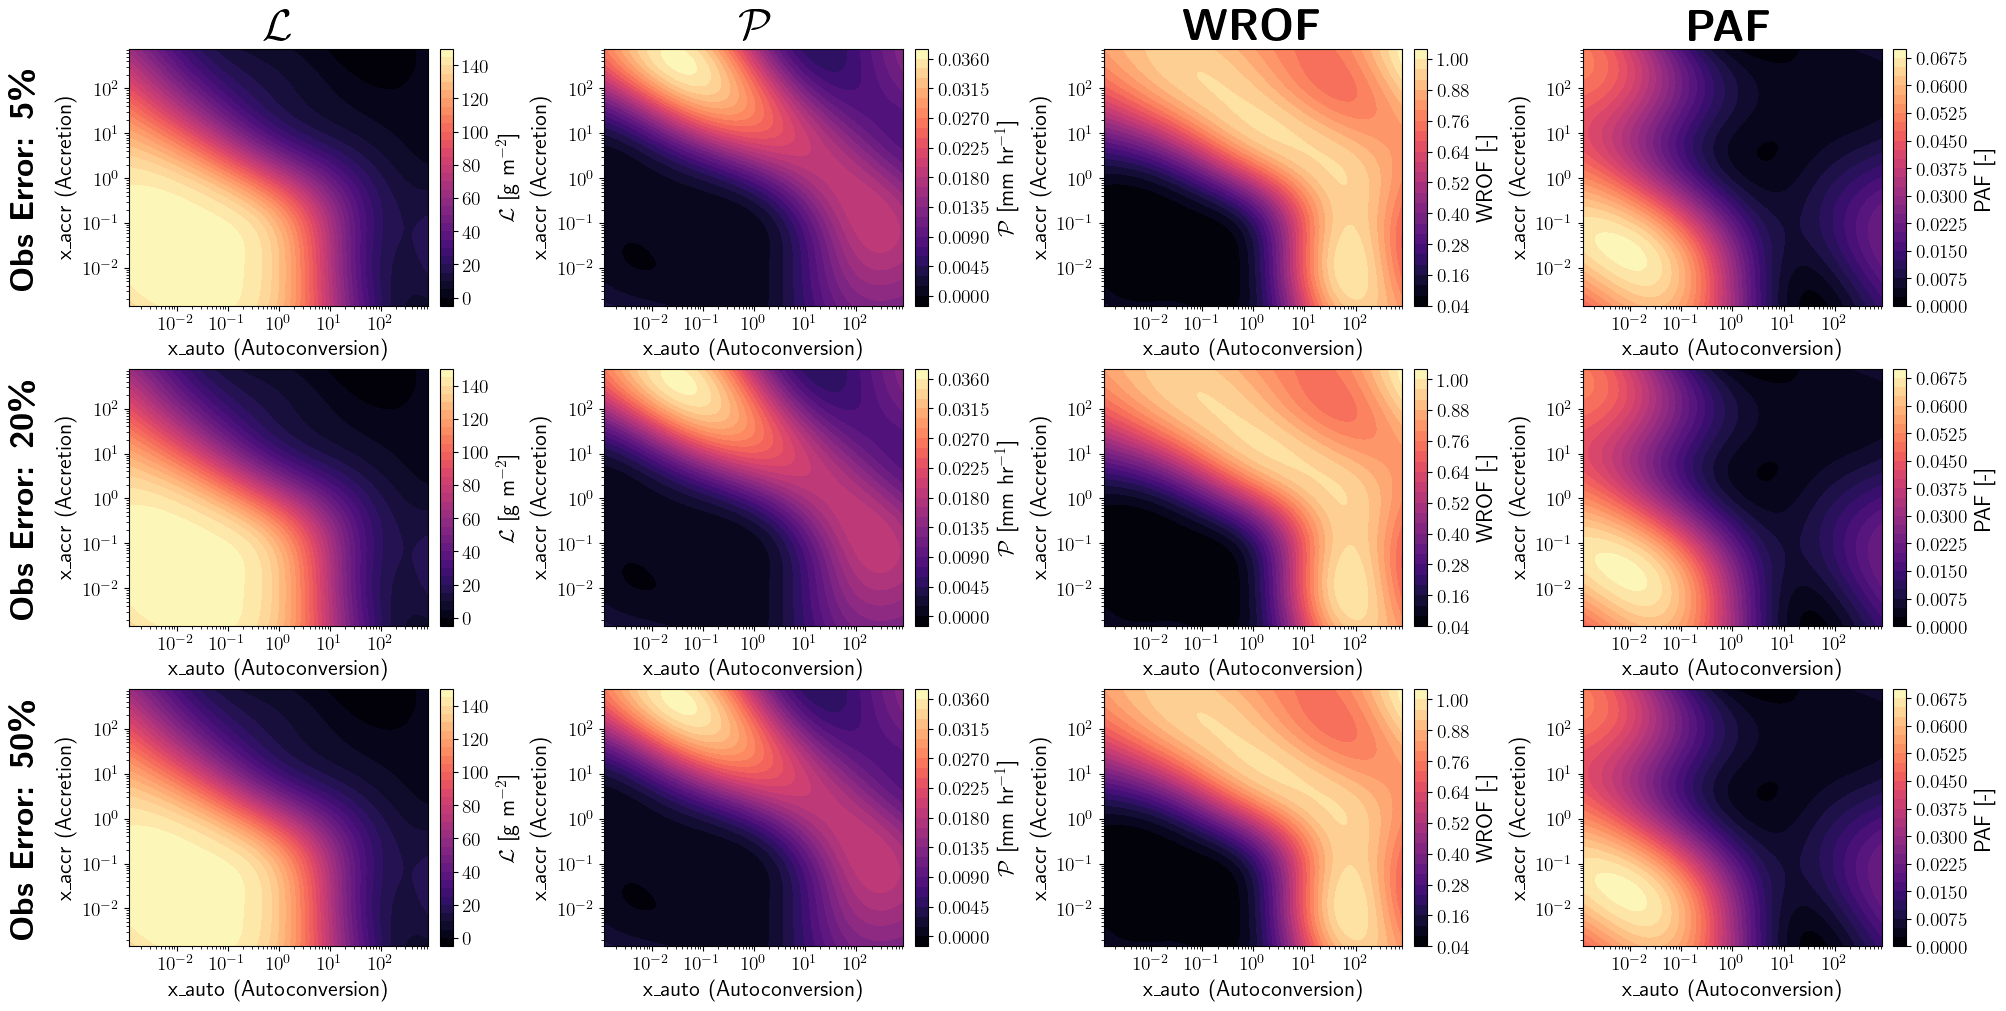

In [16]:
gp_1 = joblib.load(f'./{emulators_dir}/gp_production_LWP_PD.joblib')
gp_2 = joblib.load(f'./{emulators_dir}/gp_production_PRECL_PD.joblib')
gp_3 = joblib.load(f'./{emulators_dir}/gp_production_WROF_PD.joblib')
gp_4 = joblib.load(f'./{emulators_dir}/gp_production_PAF_PD.joblib')

gps = [gp_1,gp_2,gp_3,gp_4]
# --- Observation and error settings ---
obs = [obs_lwp_regime2,obs_precl_regime2,obs_wrof_regime2,obs_paf_regime2]          
obs_error_fraction = [0.05,0.2,0.5]              # e.g., 5% relative error
n_errs = len(obs_error_fraction)
eps = 1e-20
n_obs = len(obs)

gp_err = np.empty((n_obs, n_errs, n_points_plot, n_points_plot))
gp_pred = np.empty((n_obs, n_errs, n_points_plot, n_points_plot))


# Loop over the 2D grid
for i in range(n_points_plot):
    for j in range(n_points_plot):
        for k in range(n_obs):
            for l in range(n_errs):
                theta_point = np.array([x_auto_grid[i, j], x_accr_grid[i, j]])
        
                # With emulator uncertainty
                ll, prediction, prediction_std, obs_std = log_likelihood_plot(theta_point, gps[k], obs[k], obs_error_fraction[l],
                                                     obs_error_is_relative=True, include_emulator_uncertainty=True, eps=eps)
                gp_err[k, l, i, j] = prediction_std
                gp_pred[k, l, i, j] = prediction

# Plotting
fig, axes = plt.subplots(3, 4, figsize=(20,10), constrained_layout=True)
Fontsize = 16

axes_flat = np.ndarray.flatten(axes)
cbar_labs = ['$\mathcal{L}$ [g m$^{-2}$]','$\mathcal{P}$ [mm hr$^{-1}$]','WROF [-]','PAF [-]']
titles = [r'\textbf{$\mathcal{L}$}',r'\textbf{$\mathcal{P}$}',r'\textbf{WROF}',r'\textbf{PAF}']
for i in range(n_obs):
    for j in range(n_errs):
        ax = axes[j,i]
        c1 = ax.contourf(x_auto_physical, x_accr_physical, gp_pred[i,j,:,:], levels=30, cmap='magma')
        ax.set_xlabel("x_auto (Autoconversion)", fontsize=Fontsize)
        ax.set_ylabel("x_accr (Accretion)", fontsize=Fontsize)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.tick_params(labelsize=Fontsize - 2)
        cbar1=fig.colorbar(c1, ax=ax, fraction=0.046, pad=0.04)
        cbar1.ax.tick_params(labelsize=Fontsize - 2)
        cbar1.ax.set_ylabel(cbar_labs[i],fontsize=Fontsize)
        if j == 0.:
            ax.set_title(titles[i],fontsize=Fontsize*2.)

for i in range(3):
    dum_str = 'Obs Error: '+str(int(obs_error_fraction[i]*100.))+'\%'
    dum_str = rf'\textbf{{{dum_str}}}'
    axes[i,0].text(-0.35,0.5,dum_str,ha='center',va='center',transform=axes[i,0].transAxes,rotation=90,fontsize=Fontsize*1.5)
    
plt.show()
plt.close()



--- Pre-calculating all surfaces at high resolution... ---
  Calculating prediction surfaces...
  Calculating 'Radiation-only' likelihood surface...
  Calculating 'Rad_LWP_5' likelihood surface...
  Calculating 'Rad_LWP_20' likelihood surface...
  Calculating 'Rad_LWP_50' likelihood surface...
--- All surfaces calculated. ---


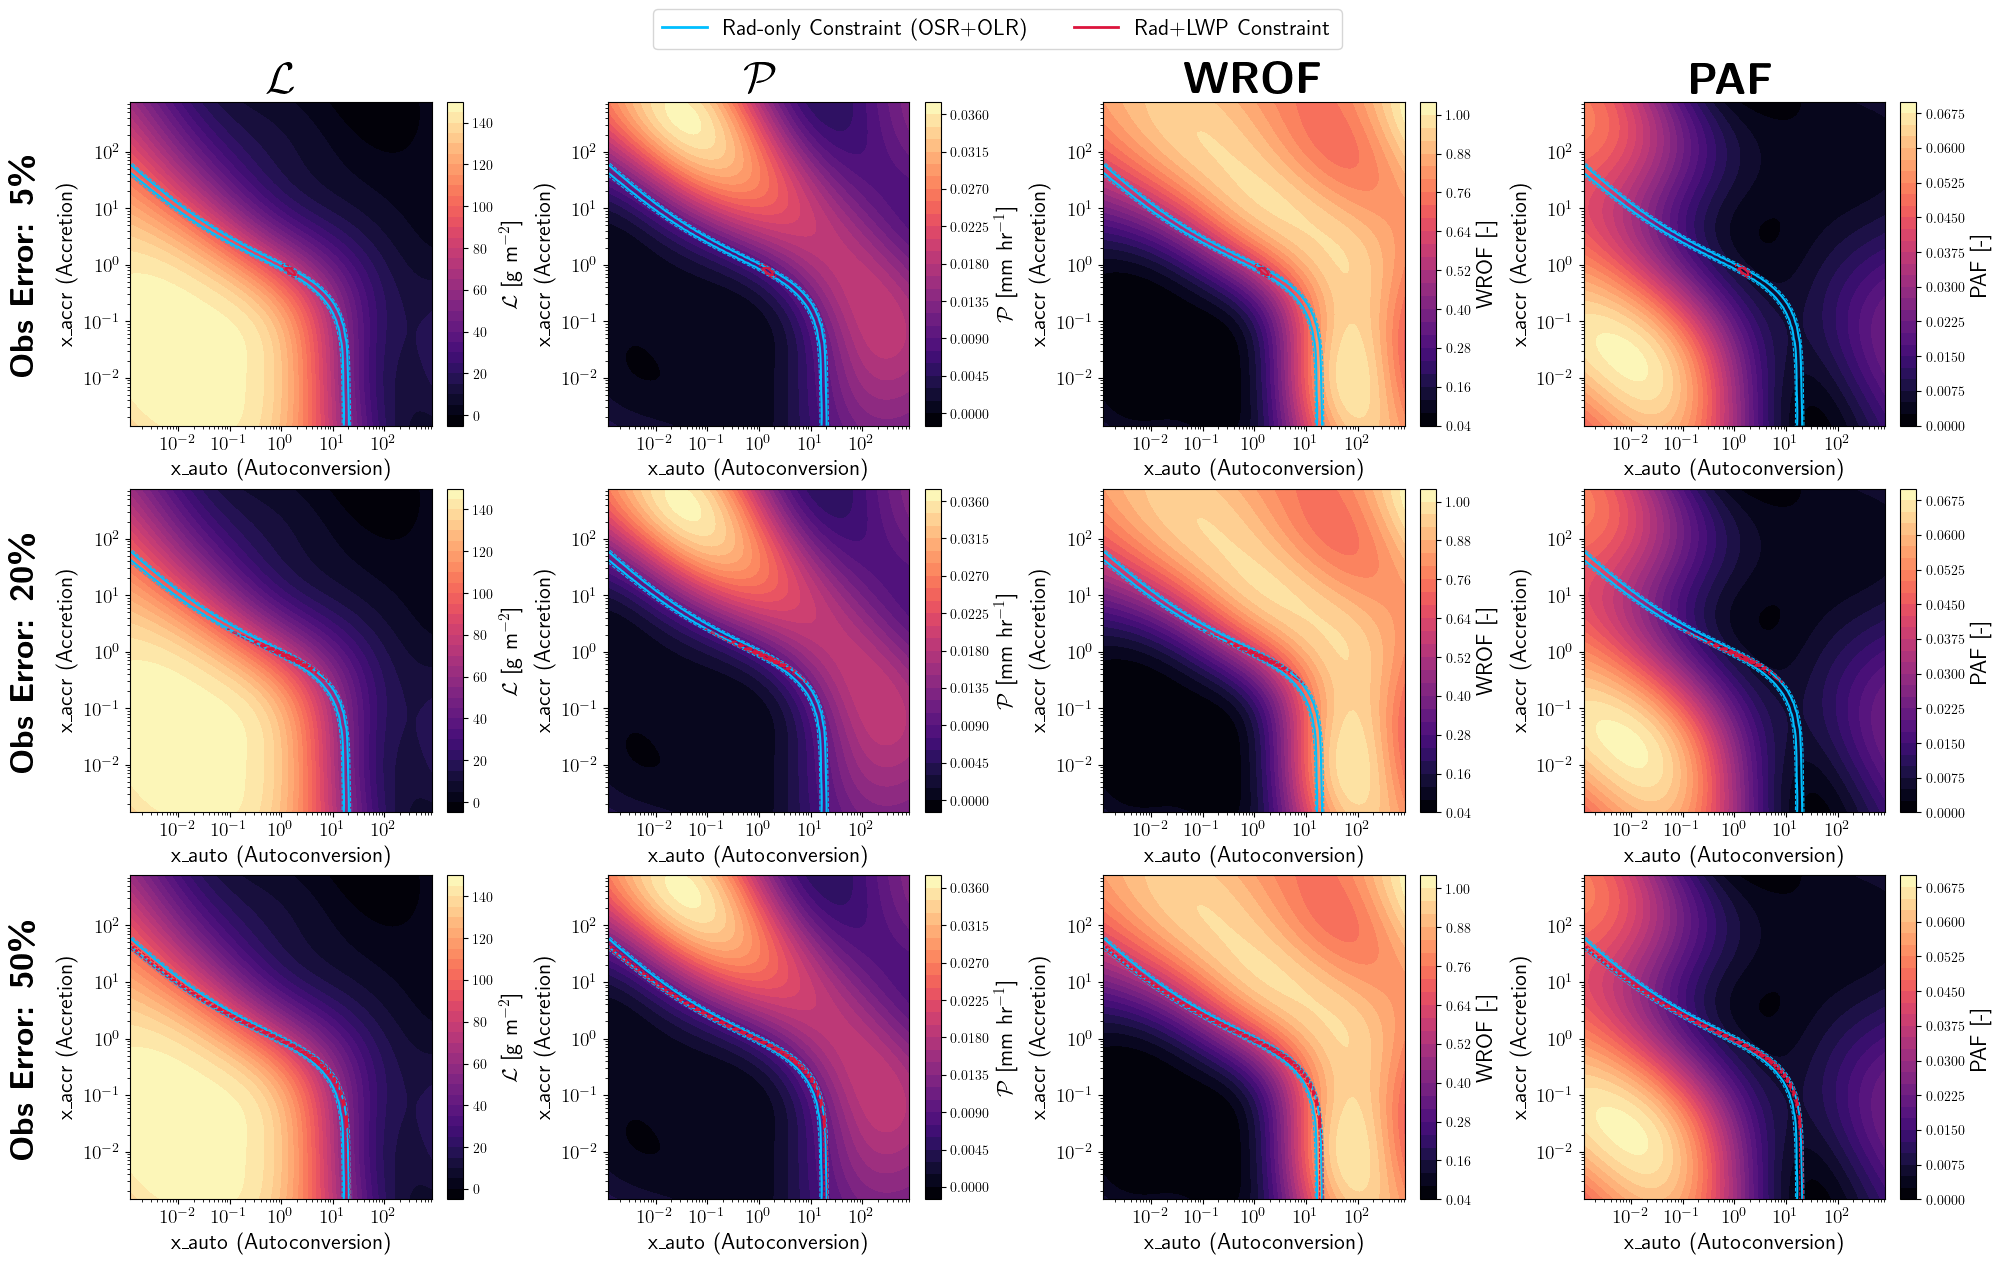

In [17]:
# This script assumes df_cntl, df_cntl_regime2, and df_dense_priors are pre-loaded.

dense_priors = joblib.load('./dense_priors_final_em_std.joblib')
df_dense_priors = pd.DataFrame.from_dict(dense_priors)

# --- 1. PRE-CALCULATION OF ALL SURFACES ---

print("--- Pre-calculating all surfaces at high resolution... ---")

# Helper function to calculate correlated log-likelihood
def calculate_correlated_likelihood_surface(theta_grid, var_list, emulators, observations, errors, R_matrix, include_emulator_uncertainty=True):
    n_points = theta_grid[0].shape[0]
    scores = np.empty((n_points, n_points))
    obs_vector = np.array([observations[v] for v in var_list])
    
    for i in range(n_points):
        for j in range(n_points):
            theta_point = np.atleast_2d([theta_grid[0][i, j], theta_grid[1][i, j]])
            pred_vector = []
            pred_stds = []
            for v in var_list:
                pred, std = emulators[v].predict(theta_point, return_std=True)
                pred_vector.append(pred[0])
                pred_stds.append(std[0])
            pred_vector = np.array(pred_vector)
            
            # This must be inside the loop to use the correct errors for each case
            current_errors = np.array([errors[v] for v in var_list])
            total_variances = current_errors**2
            if include_emulator_uncertainty:
                total_variances += np.array(pred_stds)**2
            
            total_stds = np.sqrt(total_variances)
            D_total = np.diag(total_stds)
            Sigma_total = D_total @ R_matrix @ D_total
            
            try:
                inv_Sigma_total = np.linalg.inv(Sigma_total)
                residual_vector = pred_vector - obs_vector
                mahalanobis_sq = residual_vector @ inv_Sigma_total @ residual_vector
                scores[i, j] = -0.5 * mahalanobis_sq
            except np.linalg.LinAlgError:
                scores[i, j] = -np.inf
    return scores

# --- Setup grids, emulators, and observations ---
all_vars = ['LWP_PD', 'PRECL_PD', 'WROF_PD', 'PAF_PD', 'OSR_UPWELL_PD', 'OLR_UPWELL_PD']
prediction_surfaces = {}
emulators = {}
observations = {}

global_x_scaler = joblib.load('./emulators_production_final/global_x_scaler.joblib')
n_points_plot = 100
x_auto_scaled = np.linspace(0.01, 0.99, n_points_plot)
x_accr_scaled = np.linspace(0.01, 0.99, n_points_plot)
x_auto_grid, x_accr_grid = np.meshgrid(x_auto_scaled, x_accr_scaled)

for var_name in all_vars:
    emulators[var_name] = joblib.load(f'./emulators_production_final/gp_production_{var_name}.joblib')
    if var_name in ['LWP_PD', 'PRECL_PD', 'WROF_PD', 'PAF_PD']:
        observations[var_name] = df_cntl_regime2[var_name].iloc[0]
    else:
        observations[var_name] = df_cntl[var_name].iloc[0]

# Calculate Prediction Surfaces (once)
print("  Calculating prediction surfaces...")
for var_name in ['LWP_PD', 'PRECL_PD', 'WROF_PD', 'PAF_PD']:
    preds = np.empty((n_points_plot, n_points_plot))
    for i in range(n_points_plot):
        for j in range(n_points_plot):
            theta_point = np.atleast_2d([x_auto_grid[i, j], x_accr_grid[i, j]])
            preds[i, j] = emulators[var_name].predict(theta_point)[0]
    prediction_surfaces[var_name] = preds

# --- Calculate Likelihood Surfaces ---
likelihood_surfaces = {}
obs_error_fractions = [0.05, 0.20, 0.50]
errors = {} # Base errors

# Define fixed radiation errors
errors['OLR_UPWELL_PD'] = 3.0
errors['OSR_UPWELL_PD'] = 2.0

# Calculate Rad-only surface (once, as it's constant)
print("  Calculating 'Radiation-only' likelihood surface...")
vars_rad = ['OSR_UPWELL_PD', 'OLR_UPWELL_PD']
R_rad = np.corrcoef(df_dense_priors[vars_rad].to_numpy(), rowvar=False)
likelihood_surfaces['Rad_only'] = calculate_correlated_likelihood_surface(
    (x_auto_grid, x_accr_grid), vars_rad, emulators, observations, errors, R_rad
)

# Calculate Rad+LWP surfaces for EACH error assumption
vars_rad_lwp = ['OSR_UPWELL_PD', 'OLR_UPWELL_PD', 'LWP_PD']
R_rad_lwp = np.corrcoef(df_dense_priors[vars_rad_lwp].to_numpy(), rowvar=False)
for err_frac in obs_error_fractions:
    key = f'Rad_LWP_{int(err_frac*100)}'
    print(f"  Calculating '{key}' likelihood surface...")
    # Update the LWP error for this specific calculation
    errors['LWP_PD'] = err_frac * abs(observations['LWP_PD'])
    likelihood_surfaces[key] = calculate_correlated_likelihood_surface(
        (x_auto_grid, x_accr_grid), vars_rad_lwp, emulators, observations, errors, R_rad_lwp
    )

# --- Transform coordinates for plotting ---
scaled_flat = np.stack((x_auto_grid.ravel(), x_accr_grid.ravel()), axis=-1)
log10_physical_flat = global_x_scaler.inverse_transform(scaled_flat)
x_auto_physical = (10.0 ** log10_physical_flat[:, 0]).reshape(x_auto_grid.shape)
x_accr_physical = (10.0 ** log10_physical_flat[:, 1]).reshape(x_accr_grid.shape)
print("--- All surfaces calculated. ---")


# --- 2. PLOTTING THE 3x4 FIGURE ---
fig, axes = plt.subplots(3, 4, figsize=(20, 12), constrained_layout=True)
Fontsize = 16

plot_vars = ['LWP_PD', 'PRECL_PD', 'WROF_PD', 'PAF_PD']
cbar_labs = ['$\mathcal{L}$ [g m$^{-2}$]','$\mathcal{P}$ [mm hr$^{-1}$]','WROF [-]','PAF [-]']
titles = [r'\textbf{$\mathcal{L}$}',r'\textbf{$\mathcal{P}$}',r'\textbf{WROF}',r'\textbf{PAF}']
confidence_delta_ll = [-3.09, -1.15] # 95% and 68% CIs

# Calculate Rad-only contour levels once
max_like_rad = np.nanmax(likelihood_surfaces['Rad_only'])
contour_levels_rad = max_like_rad + np.array(confidence_delta_ll)

# Main plotting loop
for i, var_name in enumerate(plot_vars): # Loop over columns
    for j, err_frac in enumerate(obs_error_fractions): # Loop over rows
        ax = axes[j, i]
        
        # Plot the prediction surface background (same for each column)
        surface_to_plot = prediction_surfaces[var_name]
        cf = ax.contourf(x_auto_physical, x_accr_physical, surface_to_plot, levels=30, cmap='magma')
        cbar = fig.colorbar(cf, ax=ax)
        cbar.ax.set_ylabel(cbar_labs[i], fontsize=Fontsize)
        
        # --- OVERLAY CONTOURS ---
        
        # 1. Overlay "Radiation-only" contours (same for all plots)
        ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces['Rad_only'], levels=contour_levels_rad,
                   colors='deepskyblue', linewidths=[0.75, 1.5], linestyles=['dashed', 'solid'])

        # 2. Overlay the correct "Radiation + LWP" contours for THIS ROW's error assumption
        rad_lwp_key = f'Rad_LWP_{int(err_frac*100)}'
        max_like_rad_lwp = np.nanmax(likelihood_surfaces[rad_lwp_key])
        contour_levels_rad_lwp = max_like_rad_lwp + np.array(confidence_delta_ll)
        ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces[rad_lwp_key], levels=contour_levels_rad_lwp,
                   colors='crimson', linewidths=[0.75,1.5], linestyles=['dashed', 'solid'])
        
        # --- FORMATTING ---
        if j == 0: # Set titles only on the top row
            ax.set_title(titles[i], fontsize=Fontsize*2.)
        
        if i == 0: # Set row labels only on the left column
            dum_str = f'Obs Error: {int(err_frac*100.)}\%'
            dum_str = rf'\textbf{{{dum_str}}}'
            ax.text(-0.35, 0.5, dum_str, ha='center', va='center', transform=ax.transAxes, rotation=90, fontsize=Fontsize*1.5)
        
        ax.set_xlabel("x_auto (Autoconversion)", fontsize=Fontsize)
        ax.set_ylabel("x_accr (Accretion)", fontsize=Fontsize)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.tick_params(labelsize=Fontsize - 2)

# Create a single legend for the whole figure
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='deepskyblue', lw=2, label='Rad-only Constraint (OSR+OLR)'),
    Line2D([0], [0], color='crimson', lw=2, label='Rad+LWP Constraint')
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2, fontsize=Fontsize)

plt.show()
plt.close()

--- Pre-calculating all surfaces at high resolution... ---
  Calculating prediction surfaces...
  Calculating 'Radiation-only' likelihood surface...
  Calculating 'Rad_LWP_5' likelihood surface...
  Calculating 'All_Constraints_5' likelihood surface...
  Calculating 'Rad_LWP_20' likelihood surface...
  Calculating 'All_Constraints_20' likelihood surface...
  Calculating 'Rad_LWP_50' likelihood surface...
  Calculating 'All_Constraints_50' likelihood surface...
--- All surfaces calculated. ---


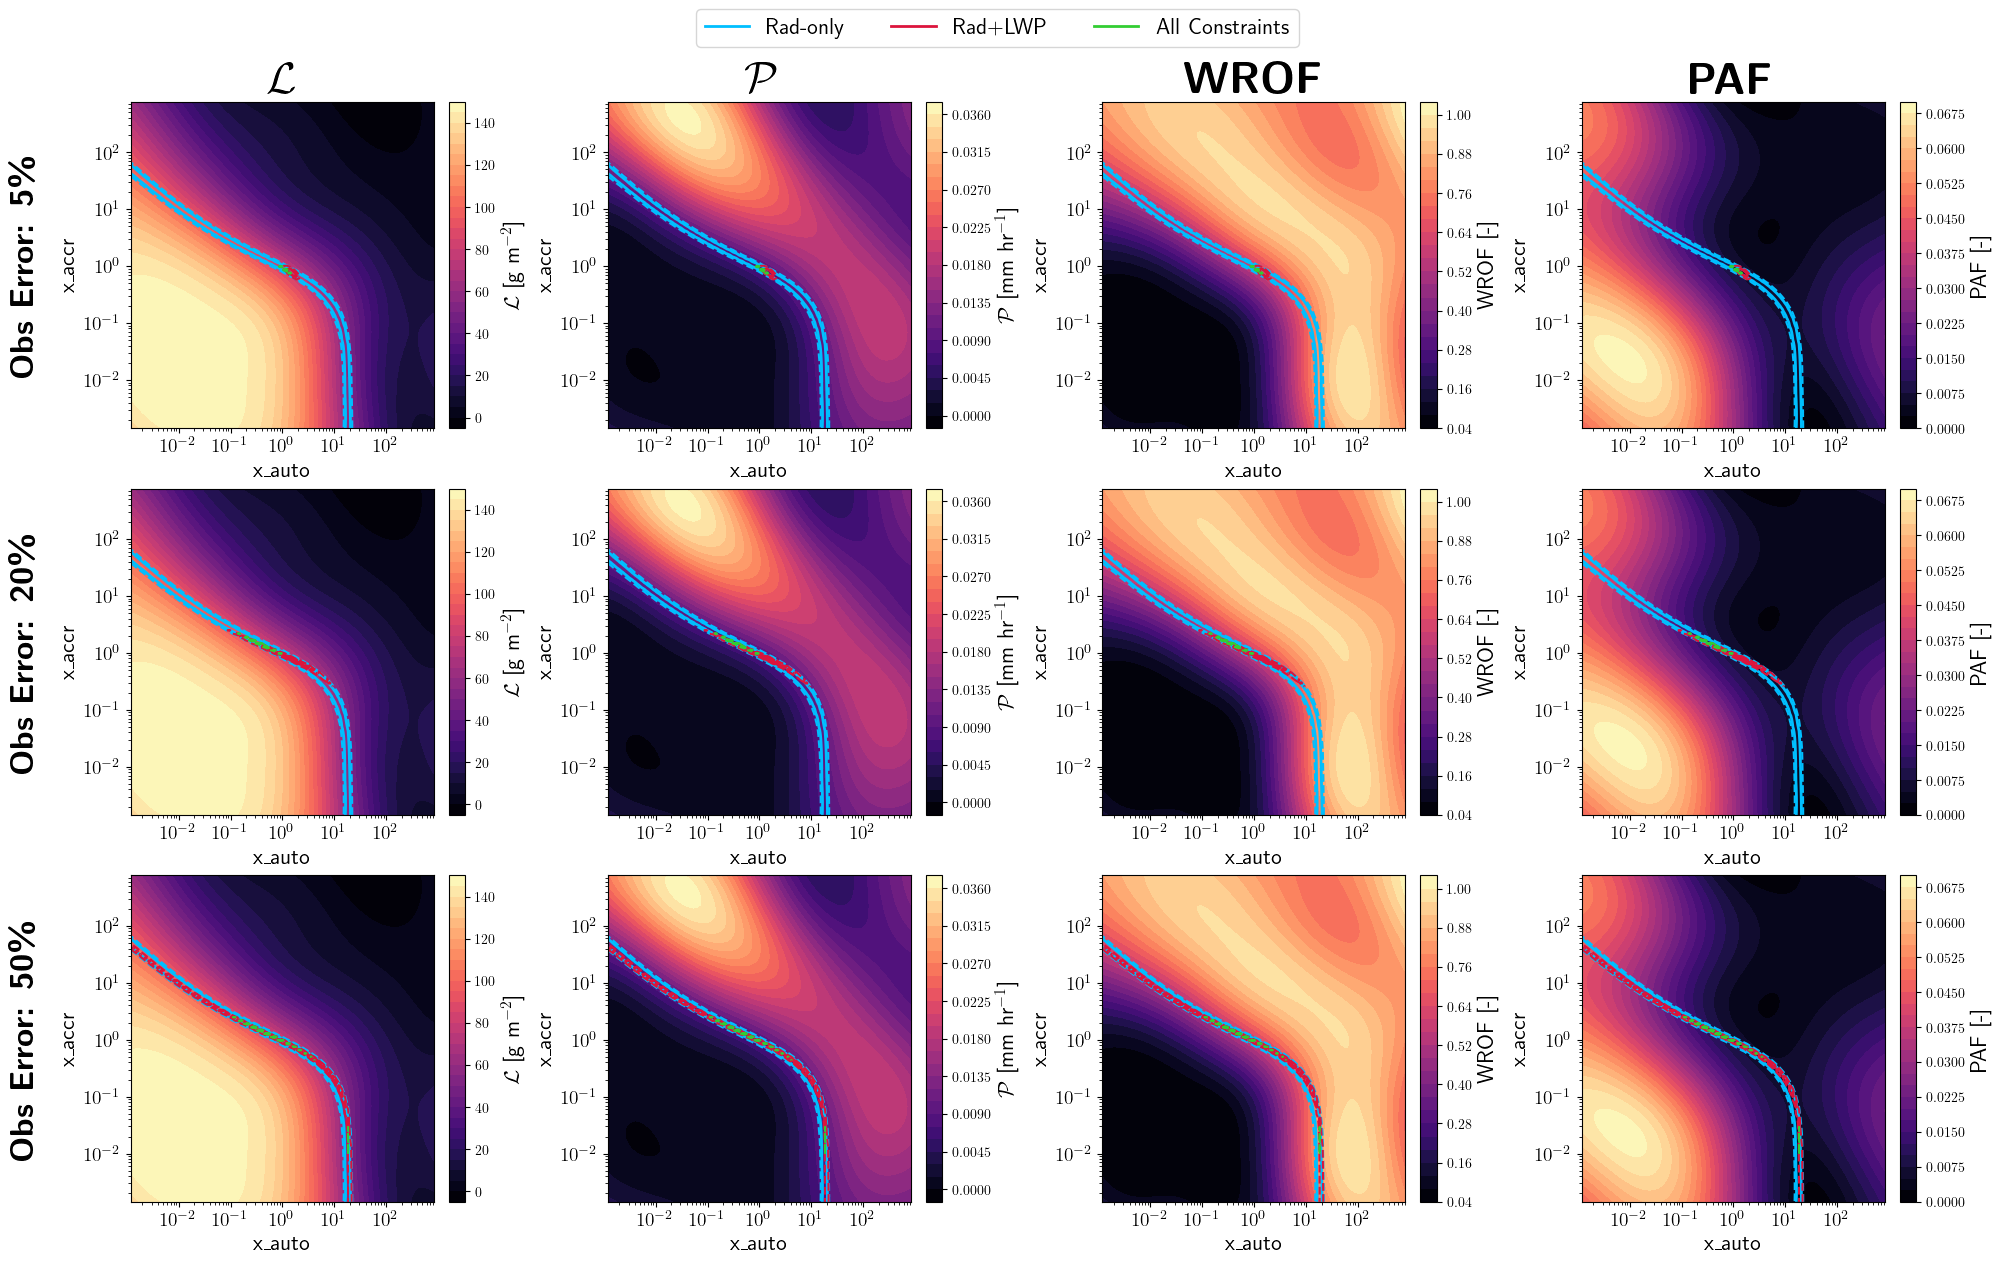

In [14]:
dense_priors = joblib.load('./dense_priors_final_em_std.joblib')
df_dense_priors = pd.DataFrame.from_dict(dense_priors)

# --- 1. PRE-CALCULATION OF ALL SURFACES ---

print("--- Pre-calculating all surfaces at high resolution... ---")

# Helper function to calculate correlated log-likelihood
def calculate_correlated_likelihood_surface(theta_grid, var_list, emulators, observations, errors, R_matrix, include_emulator_uncertainty=True):
    n_points = theta_grid[0].shape[0]
    scores = np.empty((n_points, n_points))
    obs_vector = np.array([observations[v] for v in var_list])
    
    for i in range(n_points):
        for j in range(n_points):
            theta_point = np.atleast_2d([theta_grid[0][i, j], theta_grid[1][i, j]])
            pred_vector = []
            pred_stds = []
            for v in var_list:
                pred, std = emulators[v].predict(theta_point, return_std=True)
                pred_vector.append(pred[0])
                pred_stds.append(std[0])
            pred_vector = np.array(pred_vector)
            
            current_errors = np.array([errors[v] for v in var_list])
            total_variances = current_errors**2
            if include_emulator_uncertainty:
                total_variances += np.array(pred_stds)**2
            
            total_stds = np.sqrt(total_variances)
            D_total = np.diag(total_stds)
            Sigma_total = D_total @ R_matrix @ D_total
            
            try:
                inv_Sigma_total = np.linalg.inv(Sigma_total)
                residual_vector = pred_vector - obs_vector
                mahalanobis_sq = residual_vector @ inv_Sigma_total @ residual_vector
                scores[i, j] = -0.5 * mahalanobis_sq
            except np.linalg.LinAlgError:
                scores[i, j] = -np.inf
    return scores

# --- Setup grids, emulators, and observations ---
all_vars = ['LWP_PD', 'PRECL_PD', 'WROF_PD', 'PAF_PD', 'OSR_UPWELL_PD', 'OLR_UPWELL_PD']
prediction_surfaces = {}
emulators = {}
observations = {}

global_x_scaler = joblib.load('./emulators_production_final/global_x_scaler.joblib')
n_points_plot = 100
x_auto_scaled = np.linspace(0.01, 0.99, n_points_plot)
x_accr_scaled = np.linspace(0.01, 0.99, n_points_plot)
x_auto_grid, x_accr_grid = np.meshgrid(x_auto_scaled, x_accr_scaled)

for var_name in all_vars:
    emulators[var_name] = joblib.load(f'./emulators_production_final/gp_production_{var_name}.joblib')
    if var_name in ['LWP_PD', 'PRECL_PD', 'WROF_PD', 'PAF_PD']:
        observations[var_name] = df_cntl_regime2[var_name].iloc[0]
    else:
        observations[var_name] = df_cntl[var_name].iloc[0]
        
# Calculate Prediction Surfaces (once)
print("  Calculating prediction surfaces...")
for var_name in ['LWP_PD', 'PRECL_PD', 'WROF_PD', 'PAF_PD']:
    preds = np.empty((n_points_plot, n_points_plot))
    for i in range(n_points_plot):
        for j in range(n_points_plot):
            theta_point = np.atleast_2d([x_auto_grid[i, j], x_accr_grid[i, j]])
            preds[i, j] = emulators[var_name].predict(theta_point)[0]
    prediction_surfaces[var_name] = preds

# --- Calculate Likelihood Surfaces ---
likelihood_surfaces = {}
obs_error_fractions = [0.05, 0.20, 0.50]
errors = {'OLR_UPWELL_PD': 3.0, 'OSR_UPWELL_PD': 2.0} # Base fixed errors

# Calculate Rad-only surface (once)
print("  Calculating 'Radiation-only' likelihood surface...")
vars_rad = ['OSR_UPWELL_PD', 'OLR_UPWELL_PD']
R_rad = np.corrcoef(df_dense_priors[vars_rad].to_numpy(), rowvar=False)
likelihood_surfaces['Rad_only'] = calculate_correlated_likelihood_surface(
    (x_auto_grid, x_accr_grid), vars_rad, emulators, observations, errors, R_rad
)

# Calculate Rad+LWP and Rad+LWP+Processes surfaces for EACH error assumption
vars_rad_lwp = ['OSR_UPWELL_PD', 'OLR_UPWELL_PD', 'LWP_PD']
R_rad_lwp = np.corrcoef(df_dense_priors[vars_rad_lwp].to_numpy(), rowvar=False)
vars_all = ['OSR_UPWELL_PD', 'OLR_UPWELL_PD', 'LWP_PD', 'PRECL_PD', 'WROF_PD', 'PAF_PD']
R_all = np.corrcoef(df_dense_priors[vars_all].to_numpy(), rowvar=False)

for err_frac in obs_error_fractions:
    # Update errors for this iteration
    errors['LWP_PD'] = err_frac * abs(observations['LWP_PD'])
    errors['PRECL_PD'] = err_frac * abs(observations['PRECL_PD'])
    errors['WROF_PD'] = err_frac * abs(observations['WROF_PD'])
    errors['PAF_PD'] = err_frac * abs(observations['PAF_PD'])
    
    # Calculate Rad+LWP surface
    key_rad_lwp = f'Rad_LWP_{int(err_frac*100)}'
    print(f"  Calculating '{key_rad_lwp}' likelihood surface...")
    likelihood_surfaces[key_rad_lwp] = calculate_correlated_likelihood_surface(
        (x_auto_grid, x_accr_grid), vars_rad_lwp, emulators, observations, errors, R_rad_lwp
    )
    
    # --- NEW: Calculate "All Constraints" surface ---
    key_all = f'All_Constraints_{int(err_frac*100)}'
    print(f"  Calculating '{key_all}' likelihood surface...")
    likelihood_surfaces[key_all] = calculate_correlated_likelihood_surface(
        (x_auto_grid, x_accr_grid), vars_all, emulators, observations, errors, R_all
    )

# --- Transform coordinates for plotting ---
scaled_flat = np.stack((x_auto_grid.ravel(), x_accr_grid.ravel()), axis=-1)
log10_physical_flat = global_x_scaler.inverse_transform(scaled_flat)
x_auto_physical = (10.0 ** log10_physical_flat[:, 0]).reshape(x_auto_grid.shape)
x_accr_physical = (10.0 ** log10_physical_flat[:, 1]).reshape(x_accr_grid.shape)
print("--- All surfaces calculated. ---")


# --- 2. PLOTTING THE 3x4 FIGURE ---
fig, axes = plt.subplots(3, 4, figsize=(20, 12), constrained_layout=True)
Fontsize = 16

plot_vars = ['LWP_PD', 'PRECL_PD', 'WROF_PD', 'PAF_PD']
cbar_labs = ['$\mathcal{L}$ [g m$^{-2}$]','$\mathcal{P}$ [mm hr$^{-1}$]','WROF [-]','PAF [-]']
titles = [r'\textbf{$\mathcal{L}$}',r'\textbf{$\mathcal{P}$}',r'\textbf{WROF}',r'\textbf{PAF}']
confidence_delta_ll = [-3.09, -1.15] # 95% and 68% CIs

max_like_rad = np.nanmax(likelihood_surfaces['Rad_only'])
contour_levels_rad = max_like_rad + np.array(confidence_delta_ll)

for i, var_name in enumerate(plot_vars): # Loop over columns
    for j, err_frac in enumerate(obs_error_fractions): # Loop over rows
        ax = axes[j, i]
        
        surface_to_plot = prediction_surfaces[var_name]
        cf = ax.contourf(x_auto_physical, x_accr_physical, surface_to_plot, levels=30, cmap='magma')
        cbar = fig.colorbar(cf, ax=ax)
        cbar.ax.set_ylabel(cbar_labs[i], fontsize=Fontsize)
        
        # --- OVERLAY CONTOURS ---
        
        # 1. Rad-only contours (blue)
        ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces['Rad_only'], levels=contour_levels_rad,
                   colors='deepskyblue', linewidths=[1.5, 2.0], linestyles=['dashed', 'solid'])

        # 2. Rad+LWP contours (red)
        rad_lwp_key = f'Rad_LWP_{int(err_frac*100)}'
        max_like_rad_lwp = np.nanmax(likelihood_surfaces[rad_lwp_key])
        contour_levels_rad_lwp = max_like_rad_lwp + np.array(confidence_delta_ll)
        ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces[rad_lwp_key], levels=contour_levels_rad_lwp,
                   colors='crimson', linewidths=[1.5, 2.0], linestyles=['dashed', 'solid'])

        # 3. --- NEW: "All Constraints" contours (green) ---
        all_key = f'All_Constraints_{int(err_frac*100)}'
        max_like_all = np.nanmax(likelihood_surfaces[all_key])
        contour_levels_all = max_like_all + np.array(confidence_delta_ll)
        ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces[all_key], levels=contour_levels_all,
                   colors='limegreen', linewidths=[1.5, 2.0], linestyles=['dashed', 'solid'])
        
        # --- FORMATTING ---
        if j == 0: ax.set_title(titles[i], fontsize=Fontsize*2.)
        if i == 0:
            dum_str = f'Obs Error: {int(err_frac*100.)}\%'
            dum_str = rf'\textbf{{{dum_str}}}'
            ax.text(-0.35, 0.5, dum_str, ha='center', va='center', transform=ax.transAxes, rotation=90, fontsize=Fontsize*1.5)
        
        ax.set_xlabel("x_auto", fontsize=Fontsize)
        ax.set_ylabel("x_accr", fontsize=Fontsize)
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.tick_params(labelsize=Fontsize - 2)

# Create a single legend for the whole figure
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='deepskyblue', lw=2, label='Rad-only'),
    Line2D([0], [0], color='crimson', lw=2, label='Rad+LWP'),
    Line2D([0], [0], color='limegreen', lw=2, label='All Constraints') # NEW
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3, fontsize=Fontsize)

plt.show()
plt.close()

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import joblib

# This script assumes df_cntl, df_cntl_regime2, and df_dense_priors are pre-loaded.

# --- 1. PRE-CALCULATION OF ALL SURFACES ---

print("--- Pre-calculating all surfaces at high resolution... ---")

# Helper function for a single-variable likelihood surface
def calculate_independent_likelihood_surface(theta_grid, var_name, emulator, observation, error, include_emulator_uncertainty=True):
    n_points = theta_grid[0].shape[0]
    scores = np.empty((n_points, n_points))
    for i in range(n_points):
        for j in range(n_points):
            theta_point = np.atleast_2d([theta_grid[0][i, j], theta_grid[1][i, j]])
            pred, pred_std = emulator.predict(theta_point, return_std=True)
            total_variance = error**2
            if include_emulator_uncertainty:
                total_variance += pred_std[0]**2
            scores[i, j] = -0.5 * ((pred[0] - observation)**2 / total_variance)
    return scores

# Helper function for correlated log-likelihood
def calculate_correlated_likelihood_surface(theta_grid, var_list, emulators, observations, errors, R_matrix, include_emulator_uncertainty=True):
    n_points = theta_grid[0].shape[0]
    scores = np.empty((n_points, n_points))
    obs_vector = np.array([observations[v] for v in var_list])
    
    for i in range(n_points):
        for j in range(n_points):
            theta_point = np.atleast_2d([theta_grid[0][i, j], theta_grid[1][i, j]])
            pred_vector, pred_stds = [], []
            for v in var_list:
                pred, std = emulators[v].predict(theta_point, return_std=True)
                pred_vector.append(pred[0]); pred_stds.append(std[0])
            
            current_errors = np.array([errors[v] for v in var_list])
            total_variances = current_errors**2
            if include_emulator_uncertainty:
                total_variances += np.array(pred_stds)**2
            
            total_stds = np.sqrt(total_variances)
            Sigma_total = np.diag(total_stds) @ R_matrix @ np.diag(total_stds)
            
            try:
                inv_Sigma_total = np.linalg.inv(Sigma_total)
                residual_vector = np.array(pred_vector) - obs_vector
                scores[i, j] = -0.5 * (residual_vector @ inv_Sigma_total @ residual_vector)
            except np.linalg.LinAlgError:
                scores[i, j] = -np.inf
    return scores

# --- Setup grids, emulators, and observations ---
all_vars = ['ERF_ACI','LWP_PD', 'PRECL_PD', 'WROF_PD', 'PAF_PD', 'OSR_UPWELL_PD', 'OLR_UPWELL_PD']
prediction_surfaces, emulators, observations = {}, {}, {}

global_x_scaler = joblib.load('./emulators_production_final/global_x_scaler.joblib')
n_points_plot = 100
x_auto_scaled = np.linspace(0.01, 0.99, n_points_plot)
x_accr_scaled = np.linspace(0.01, 0.99, n_points_plot)
x_auto_grid, x_accr_grid = np.meshgrid(x_auto_scaled, x_accr_scaled)

for var_name in all_vars:
    emulators[var_name] = joblib.load(f'./emulators_production_final/gp_production_{var_name}.joblib')
    observations[var_name] = df_cntl_regime2[var_name].iloc[0] if var_name in ['LWP_PD', 'PRECL_PD', 'WROF_PD', 'PAF_PD'] else df_cntl[var_name].iloc[0]

# --- Calculate Prediction Surfaces (once) ---
print("  Calculating prediction surfaces...")
for var_name in ['ERF_ACI','LWP_PD', 'PRECL_PD', 'WROF_PD', 'PAF_PD']:
    preds = np.empty((n_points_plot, n_points_plot))
    for i in range(n_points_plot):
        for j in range(n_points_plot):
            preds[i, j] = emulators[var_name].predict(np.atleast_2d([x_auto_grid[i, j], x_accr_grid[i, j]]))[0]
    prediction_surfaces[var_name] = preds

# --- Calculate ALL Likelihood Surfaces ---
likelihood_surfaces = {}
obs_error_fractions = [0.05, 0.20, 0.50]
errors = {'OLR_UPWELL_PD': 3.0, 'OSR_UPWELL_PD': 2.0}

# Rad-only surface (once)
print("  Calculating 'Radiation-only' likelihood surface...")
vars_rad = ['OSR_UPWELL_PD', 'OLR_UPWELL_PD']
R_rad = np.corrcoef(df_dense_priors[vars_rad].to_numpy(), rowvar=False)
likelihood_surfaces['Rad_only'] = calculate_correlated_likelihood_surface((x_auto_grid, x_accr_grid), vars_rad, emulators, observations, errors, R_rad)

# LWP-only and Process-only surfaces for EACH error assumption
vars_proc = ['PRECL_PD', 'WROF_PD', 'PAF_PD']
R_proc = np.corrcoef(df_dense_priors[vars_proc].to_numpy(), rowvar=False)
for err_frac in obs_error_fractions:
    err_key = f'_{int(err_frac*100)}'
    print(f"  Calculating surfaces for {int(err_frac*100)}% error...")
    
    # Update errors for this iteration
    errors['LWP_PD'] = err_frac * abs(observations['LWP_PD'])
    errors['PRECL_PD'] = err_frac * abs(observations['PRECL_PD'])
    errors['WROF_PD'] = err_frac * abs(observations['WROF_PD'])
    errors['PAF_PD'] = err_frac * abs(observations['PAF_PD'])
    
    # Calculate LWP-only INDEPENDENT surface
    likelihood_surfaces[f'LWP_only{err_key}'] = calculate_independent_likelihood_surface(
        (x_auto_grid, x_accr_grid), 'LWP_PD', emulators['LWP_PD'], observations['LWP_PD'], errors['LWP_PD']
    )
    
    # Calculate Process-only CORRELATED surface
    likelihood_surfaces[f'Proc_only{err_key}'] = calculate_correlated_likelihood_surface(
        (x_auto_grid, x_accr_grid), vars_proc, emulators, observations, errors, R_proc
    )

# --- Transform coordinates for plotting ---
scaled_flat = np.stack((x_auto_grid.ravel(), x_accr_grid.ravel()), axis=-1)
log10_physical_flat = global_x_scaler.inverse_transform(scaled_flat)
x_auto_physical = (10.0 ** log10_physical_flat[:, 0]).reshape(x_auto_grid.shape)
x_accr_physical = (10.0 ** log10_physical_flat[:, 1]).reshape(x_accr_grid.shape)
print("--- All surfaces calculated. ---")


--- Pre-calculating all surfaces at high resolution... ---
  Calculating prediction surfaces...
  Calculating 'Radiation-only' likelihood surface...
  Calculating surfaces for 5% error...
  Calculating surfaces for 20% error...
  Calculating surfaces for 50% error...
--- All surfaces calculated. ---


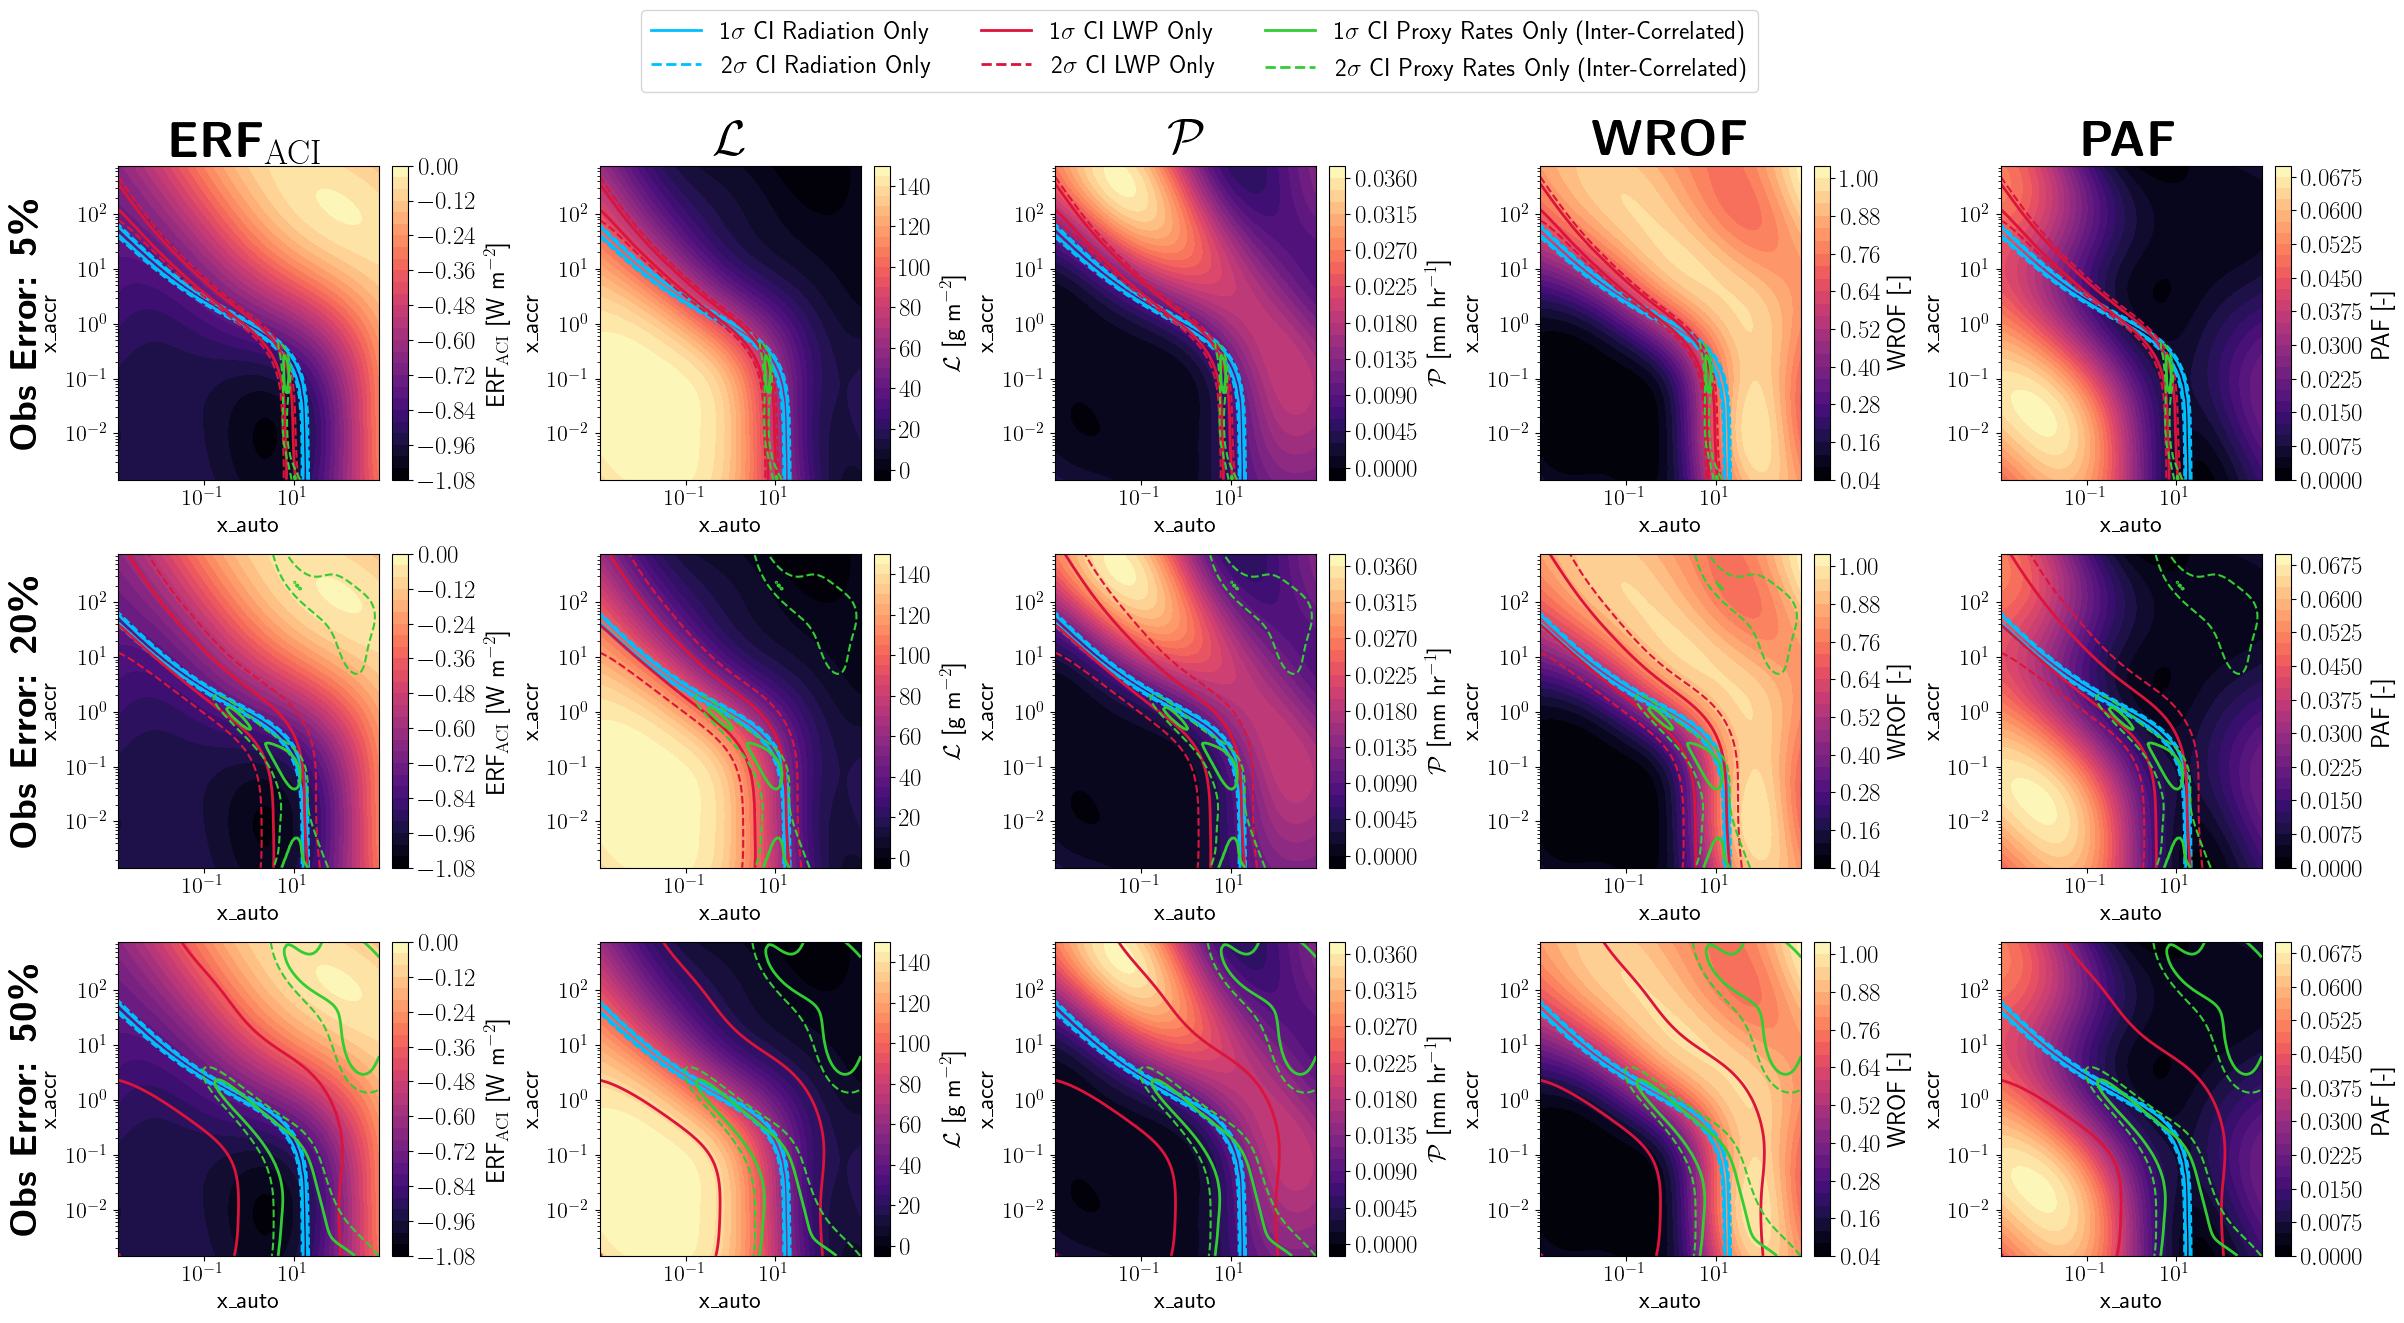

In [27]:

# --- 2. PLOTTING THE 3x4 FIGURE ---
fig, axes = plt.subplots(3, 5, figsize=(24, 12), constrained_layout=True)
Fontsize = 18

plot_vars = ['ERF_ACI','LWP_PD', 'PRECL_PD', 'WROF_PD', 'PAF_PD']
cbar_labs = ['ERF$_{\mathrm{ACI}}$ [W m$^{-2}$]','$\mathcal{L}$ [g m$^{-2}$]','$\mathcal{P}$ [mm hr$^{-1}$]','WROF [-]','PAF [-]']
titles = [r'\textbf{ERF$_{\mathrm{ACI}}$}',r'\textbf{$\mathcal{L}$}',r'\textbf{$\mathcal{P}$}',r'\textbf{WROF}',r'\textbf{PAF}']
confidence_delta_ll = [-3.09, -1.15] # 95% and 68% CIs

# Calculate Rad-only contour levels once
max_like_rad = np.nanmax(likelihood_surfaces['Rad_only'])
contour_levels_rad = max_like_rad + np.array(confidence_delta_ll)

for i, var_name in enumerate(plot_vars): # Loop over columns
    for j, err_frac in enumerate(obs_error_fractions): # Loop over rows
        ax = axes[j, i]
        
        surface_to_plot = prediction_surfaces[var_name]
        cf = ax.contourf(x_auto_physical, x_accr_physical, surface_to_plot, levels=30, cmap='magma')
        cbar = fig.colorbar(cf, ax=ax)
        cbar.ax.set_ylabel(cbar_labs[i], fontsize=Fontsize)
        cbar.ax.tick_params(labelsize=Fontsize)
        
        # --- OVERLAY ALL THREE CONTOUR SETS ---
        
        # 1. Rad-only (blue)
        ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces['Rad_only'], levels=contour_levels_rad, colors='deepskyblue', linewidths=[1.5, 2.0], linestyles=['dashed', 'solid'])

        # 2. LWP-only (red) for this row's error
        lwp_key = f'LWP_only_{int(err_frac*100)}'
        max_like_lwp = np.nanmax(likelihood_surfaces[lwp_key])
        contour_levels_lwp = max_like_lwp + np.array(confidence_delta_ll)
        ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces[lwp_key], levels=contour_levels_lwp, colors='crimson', linewidths=[1.5, 2.0], linestyles=['dashed', 'solid'])
        
        # 3. Process-only (green) for this row's error
        proc_key = f'Proc_only_{int(err_frac*100)}'
        max_like_proc = np.nanmax(likelihood_surfaces[proc_key])
        contour_levels_proc = max_like_proc + np.array(confidence_delta_ll)
        ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces[proc_key], levels=contour_levels_proc, colors='limegreen', linewidths=[1.5, 2.0], linestyles=['dashed', 'solid'])
        
        # --- FORMATTING ---
        if j == 0: ax.set_title(titles[i], fontsize=Fontsize*2.)
        if i == 0:
            dum_str = f'Obs Error: {int(err_frac*100.)}\%'
            dum_str = rf'\textbf{{{dum_str}}}'
            ax.text(-0.35, 0.5, dum_str, ha='center', va='center', transform=ax.transAxes, rotation=90, fontsize=Fontsize*1.5)
        
        ax.set_xlabel("x_auto", fontsize=Fontsize)
        ax.set_ylabel("x_accr", fontsize=Fontsize)
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.tick_params(labelsize=Fontsize - 2)

# Create a single legend for the whole figure
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='deepskyblue', lw=2, label='1$\sigma$ CI Radiation Only'),
    Line2D([0], [0], color='deepskyblue', lw=2, ls='dashed', label='2$\sigma$ CI Radiation Only'),
    Line2D([0], [0], color='crimson', lw=2, label='1$\sigma$ CI LWP Only'),
    Line2D([0], [0], color='crimson', lw=2, ls='dashed', label='2$\sigma$ CI LWP Only'),
    Line2D([0], [0], color='limegreen', lw=2, label='1$\sigma$ CI  Proxy Rates Only (Inter-Correlated)'),
    Line2D([0], [0], color='limegreen', lw=2, ls='dashed', label='2$\sigma$ CI  Proxy Rates Only (Inter-Correlated)'),
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=3, fontsize=Fontsize)

plt.show()
plt.close()

In [12]:
print('obs_lwp_regime2:',obs_lwp_regime2)
print('obs_precl_regime2:',obs_precl_regime2)
print('obs_wrof_regime2:',obs_wrof_regime2)
print('obs_paf_regime2:',obs_paf_regime2)

obs_lwp_regime2: 78.1910750903092
obs_precl_regime2: 0.007228559464281249
obs_wrof_regime2: 0.6220090564496313
obs_paf_regime2: 0.008270797330246807


--- Pre-calculating all surfaces at high resolution... ---
  Calculating prediction surfaces...
  Calculating 'Radiation-only' surface...
  Calculating individual constraint surfaces for 5% error...
  Calculating individual constraint surfaces for 20% error...
  Calculating individual constraint surfaces for 50% error...
--- All surfaces calculated. ---


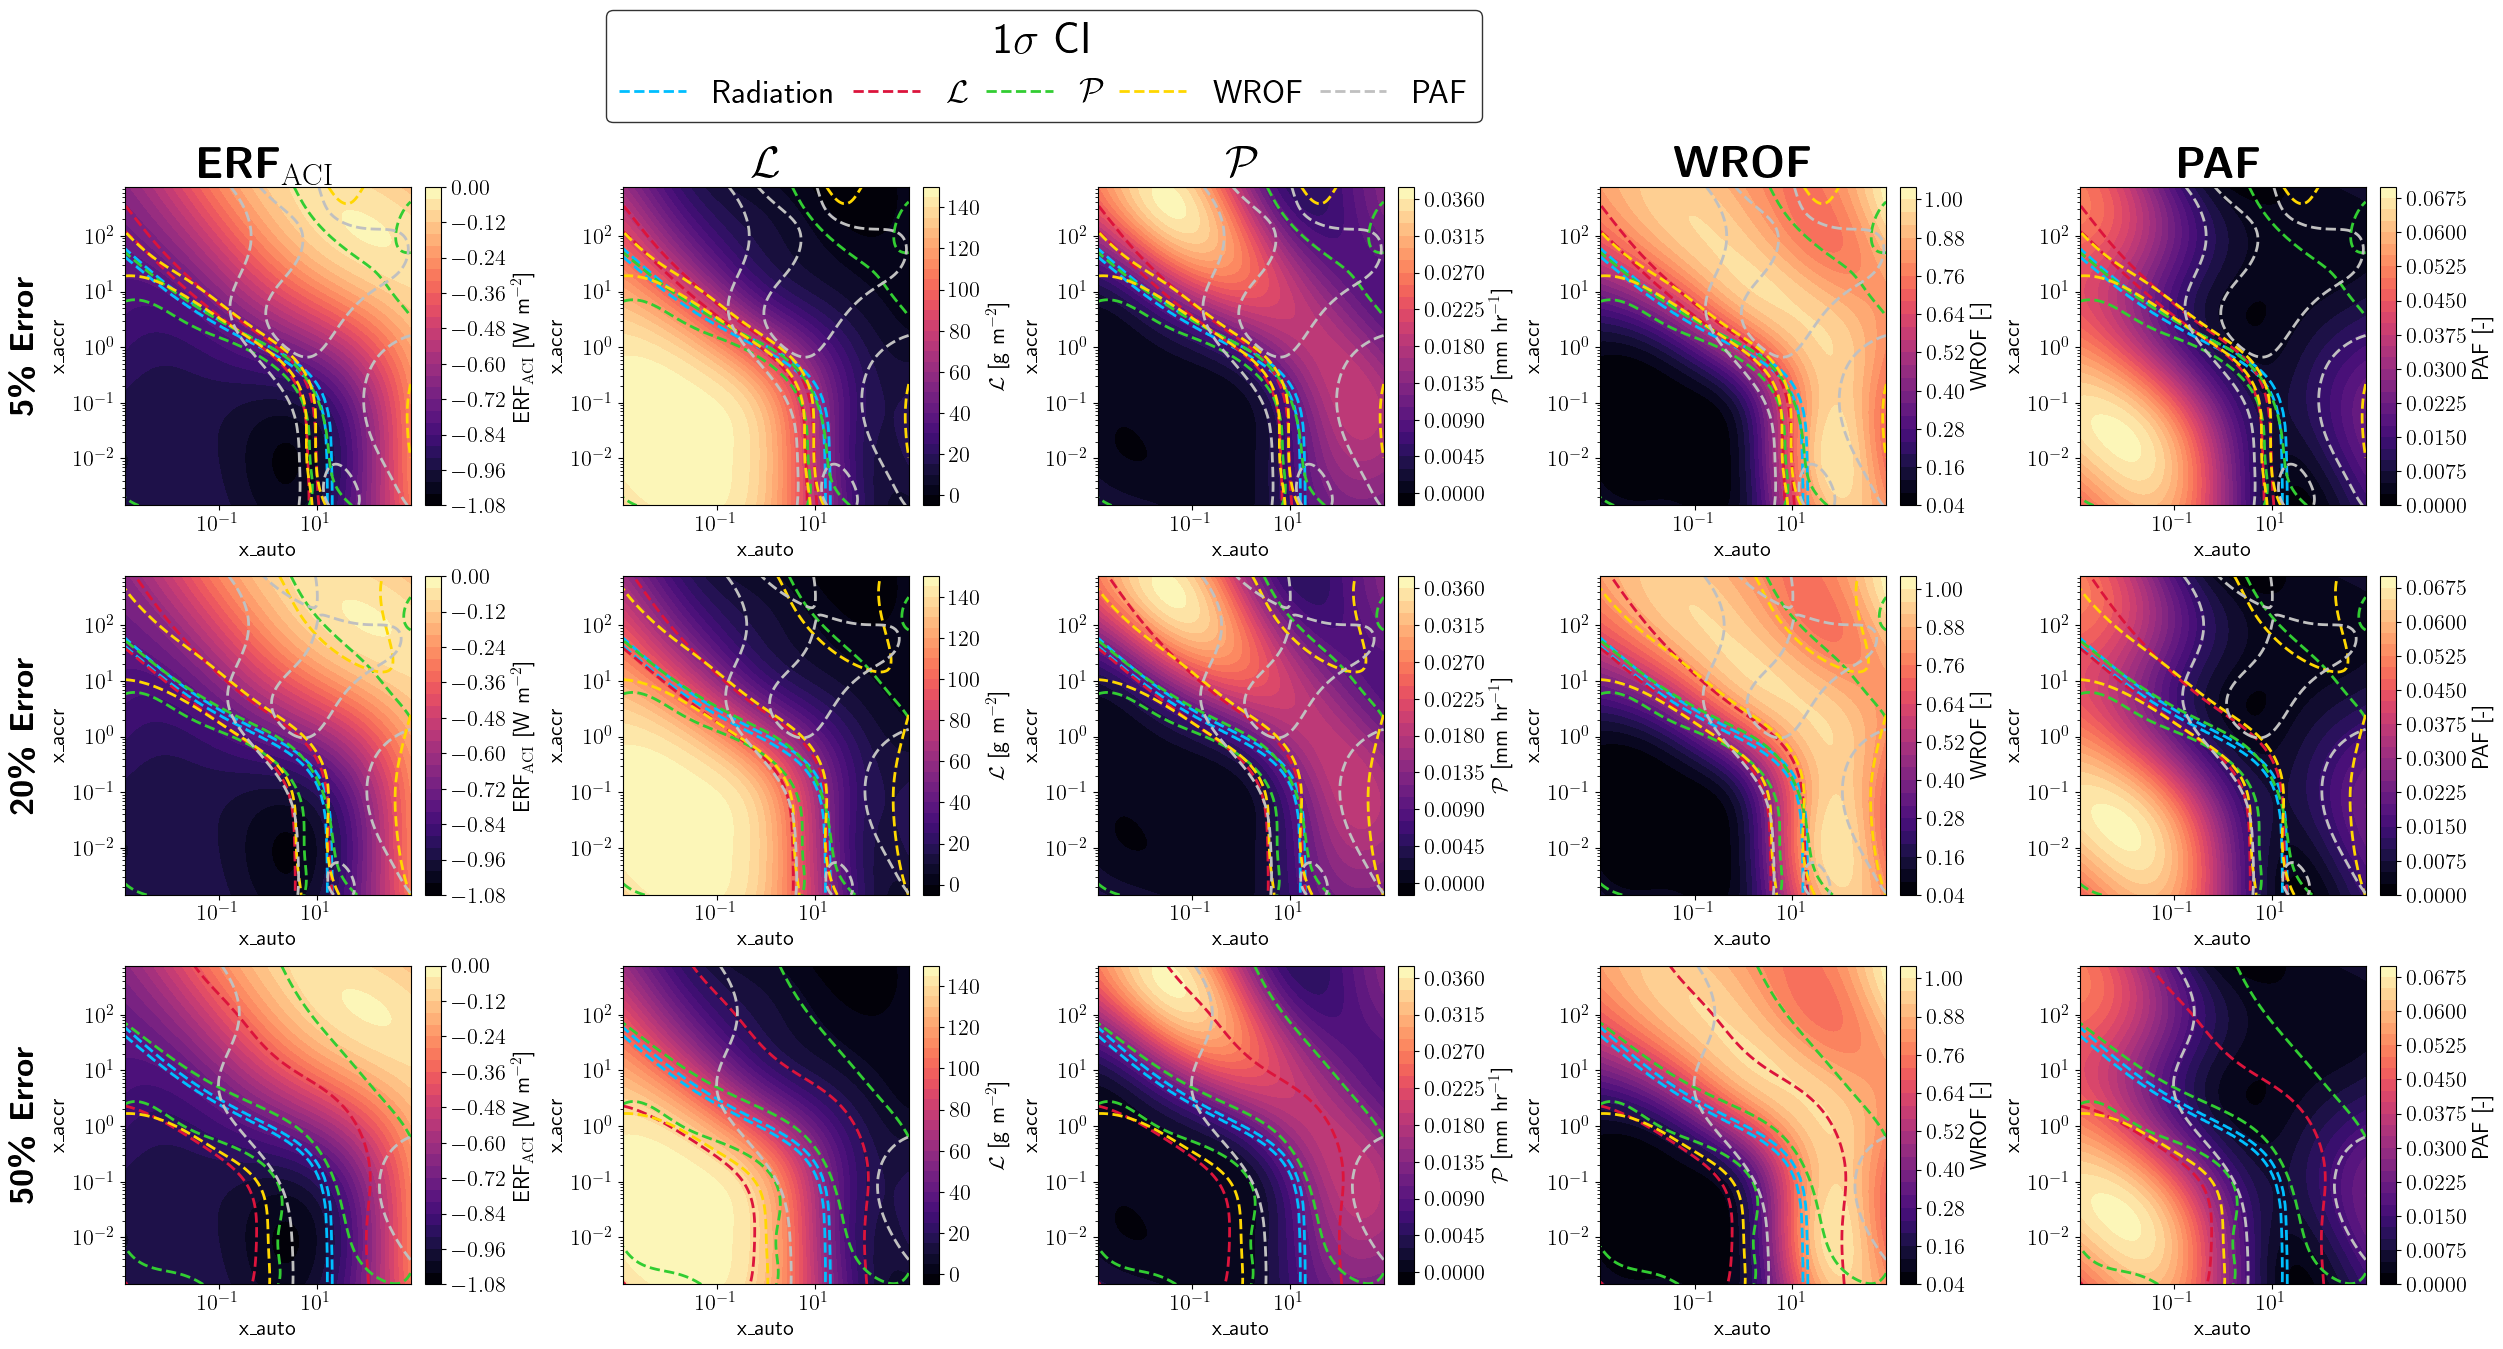

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import joblib

# This script assumes df_cntl, df_cntl_regime2, and df_dense_priors are pre-loaded.

# --- 1. PRE-CALCULATION OF ALL SURFACES ---

print("--- Pre-calculating all surfaces at high resolution... ---")

# Helper function for a single-variable likelihood surface
def calculate_independent_likelihood_surface(theta_grid, emulator, observation, error, include_emulator_uncertainty=True):
    n_points = theta_grid[0].shape[0]
    scores = np.empty((n_points, n_points))
    for i in range(n_points):
        for j in range(n_points):
            theta_point = np.atleast_2d([theta_grid[0][i, j], theta_grid[1][i, j]])
            pred, pred_std = emulator.predict(theta_point, return_std=True)
            total_variance = error**2
            if include_emulator_uncertainty: total_variance += pred_std[0]**2
            scores[i, j] = -0.5 * ((pred[0] - observation)**2 / total_variance)
    return scores

# Helper function for correlated log-likelihood
def calculate_correlated_likelihood_surface(theta_grid, var_list, emulators, observations, errors, R_matrix, include_emulator_uncertainty=True):
    # --- START OF CORRECTION ---
    # Define n_points first, then use it.
    n_points = theta_grid[0].shape[0]
    scores = np.empty((n_points, n_points))
    # --- END OF CORRECTION ---
    
    obs_vector = np.array([observations[v] for v in var_list])
    
    for i in range(n_points):
        for j in range(n_points):
            theta_point = np.atleast_2d([theta_grid[0][i, j], theta_grid[1][i, j]])
            pred_vector, pred_stds = [], []
            for v in var_list:
                pred, std = emulators[v].predict(theta_point, return_std=True)
                pred_vector.append(pred[0]); pred_stds.append(std[0])
            current_errors = np.array([errors[v] for v in var_list])
            total_variances = current_errors**2
            if include_emulator_uncertainty: total_variances += np.array(pred_stds)**2
            total_stds = np.sqrt(total_variances)
            Sigma_total = np.diag(total_stds) @ R_matrix @ np.diag(total_stds)
            try:
                inv_Sigma_total = np.linalg.inv(Sigma_total)
                residual_vector = np.array(pred_vector) - obs_vector
                scores[i, j] = -0.5 * (residual_vector @ inv_Sigma_total @ residual_vector)
            except np.linalg.LinAlgError: scores[i, j] = -np.inf
    return scores

# --- Setup grids, emulators, and observations ---
all_vars = ['ERF_ACI', 'LWP_PD', 'PRECL_PD', 'WROF_PD', 'PAF_PD', 'OSR_UPWELL_PD', 'OLR_UPWELL_PD', 'RESTOM_PD']
prediction_surfaces, emulators, observations = {}, {}, {}
global_x_scaler = joblib.load('./emulators_production_final/global_x_scaler.joblib')
n_points_plot = 150
x_auto_scaled = np.linspace(0.01, 0.99, n_points_plot)
x_accr_scaled = np.linspace(0.01, 0.99, n_points_plot)
x_auto_grid, x_accr_grid = np.meshgrid(x_auto_scaled, x_accr_scaled)

for var_name in all_vars:
    emulators[var_name] = joblib.load(f'./emulators_production_final/gp_production_{var_name}.joblib')
    observations[var_name] = df_cntl_regime2[var_name].iloc[0] if var_name in ['ERF_ACI', 'LWP_PD', 'PRECL_PD', 'WROF_PD', 'PAF_PD'] else df_cntl[var_name].iloc[0]

# --- Calculate Prediction Surfaces (once) ---
print("  Calculating prediction surfaces...")
for var_name in ['ERF_ACI', 'LWP_PD', 'PRECL_PD', 'WROF_PD', 'PAF_PD']:
    preds = np.empty((n_points_plot, n_points_plot))
    for i in range(n_points_plot):
        for j in range(n_points_plot):
            preds[i, j] = emulators[var_name].predict(np.atleast_2d([x_auto_grid[i, j], x_accr_grid[i, j]]))[0]
    prediction_surfaces[var_name] = preds

# --- Calculate ALL Likelihood Surfaces ---
likelihood_surfaces = {}
obs_error_fractions = [0.05, 0.20, 0.50]
errors = {'OLR_UPWELL_PD': 3.0, 'OSR_UPWELL_PD': 2.0}

# Rad-only surface (once)
print("  Calculating 'Radiation-only' surface...")
vars_rad = ['OSR_UPWELL_PD', 'OLR_UPWELL_PD']
R_rad = np.corrcoef(df_dense_priors[vars_rad].to_numpy(), rowvar=False)
likelihood_surfaces['Rad_only'] = calculate_correlated_likelihood_surface((x_auto_grid, x_accr_grid), vars_rad, emulators, observations, errors, R_rad)

# Individual constraint surfaces for EACH error assumption
for err_frac in obs_error_fractions:
    err_key = f'_{int(err_frac*100)}'
    print(f"  Calculating individual constraint surfaces for {int(err_frac*100)}% error...")
    for var_name in ['LWP_PD', 'PRECL_PD', 'WROF_PD', 'PAF_PD']:
        current_error = err_frac * abs(observations[var_name])
        likelihood_surfaces[f'{var_name}{err_key}'] = calculate_independent_likelihood_surface(
            (x_auto_grid, x_accr_grid), emulators[var_name], observations[var_name], current_error
        )

# --- Transform coordinates for plotting ---
scaled_flat = np.stack((x_auto_grid.ravel(), x_accr_grid.ravel()), axis=-1)
log10_physical_flat = global_x_scaler.inverse_transform(scaled_flat)
x_auto_physical = (10.0 ** log10_physical_flat[:, 0]).reshape(x_auto_grid.shape)
x_accr_physical = (10.0 ** log10_physical_flat[:, 1]).reshape(x_accr_grid.shape)
print("--- All surfaces calculated. ---")

In [ ]:
# --- 2. PLOTTING THE 3x5 FIGURE ---
fig, axes = plt.subplots(3, 5, figsize=(25, 12), constrained_layout=True)
Fontsize = 16

plot_vars = ['ERF_ACI', 'LWP_PD', 'PRECL_PD', 'WROF_PD', 'PAF_PD']
cbar_labs = [r'ERF$_{\mathrm{ACI}}$ [W m$^{-2}$]', '$\mathcal{L}$ [g m$^{-2}$]', '$\mathcal{P}$ [mm hr$^{-1}$]', 'WROF [-]', 'PAF [-]']
titles = [r'\textbf{ERF$_{\mathrm{ACI}}$}', r'\textbf{$\mathcal{L}$}', r'\textbf{$\mathcal{P}$}', r'\textbf{WROF}', r'\textbf{PAF}']
one_sigma_delta = -1.15 # For 68% CI
two_sigma_delta = -3.09 # For 95% CI

max_like_rad = np.nanmax(likelihood_surfaces['Rad_only'])
contour_level_rad = [max_like_rad + one_sigma_delta]
#contour_level_rad = [max_like_rad + two_sigma_delta]

contour_info = {
    'Rad_only': {'color': 'deepskyblue', 'label': 'Radiation'},
    'LWP_PD':   {'color': 'crimson',     'label': '$\mathcal{L}$'},
    'PRECL_PD': {'color': 'limegreen',   'label': '$\mathcal{P}$'},
    'WROF_PD':  {'color': 'gold',        'label': 'WROF'},
    'PAF_PD':   {'color': 'silver',  'label': 'PAF'}
}

for i, var_name in enumerate(plot_vars): # Loop over columns
    for j, err_frac in enumerate(obs_error_fractions): # Loop over rows
        ax = axes[j, i]
        
        surface_to_plot = prediction_surfaces[var_name]
        cf = ax.contourf(x_auto_physical, x_accr_physical, surface_to_plot, levels=30, cmap='magma')
        cbar = fig.colorbar(cf, ax=ax)
        cbar.ax.set_ylabel(cbar_labs[i], fontsize=Fontsize)
        cbar.ax.tick_params(labelsize=Fontsize)
        
        ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces['Rad_only'], levels=contour_level_rad, colors=[contour_info['Rad_only']['color']], linewidths=2)
        
        for contour_var in ['LWP_PD', 'PRECL_PD', 'WROF_PD', 'PAF_PD']:
            key = f'{contour_var}_{int(err_frac*100)}'
            max_like = np.nanmax(likelihood_surfaces[key])
            contour_level = [max_like + one_sigma_delta]
            #contour_level = [max_like + two_sigma_delta]
            ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces[key], levels=contour_level, colors=[contour_info[contour_var]['color']], linewidths=2)
        
        if j == 0: ax.set_title(titles[i], fontsize=Fontsize*2.)
        if i == 0:
            ax.text(-0.35, 0.5, f'\\textbf{{{int(err_frac*100.)}\% Error}}', ha='center', va='center', transform=ax.transAxes, rotation=90, fontsize=Fontsize*1.5)
        
        ax.set_xlabel("x_auto", fontsize=Fontsize)
        ax.set_ylabel("x_accr", fontsize=Fontsize)
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.tick_params(labelsize=Fontsize)

from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=info['color'], lw=2, ls = 'dashed', label=info['label']) for key, info in contour_info.items()]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.6, 1.125), ncol=5, fontsize=Fontsize*1.5,\
           title='1$\sigma$ CI',title_fontsize=Fontsize*2.,edgecolor='k',columnspacing=0.5)

plt.show()
plt.close()

In [13]:
dense_priors = joblib.load('./dense_priors_final_em_std.joblib')
df_dense_priors = pd.DataFrame.from_dict(dense_priors)

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import joblib

# This script assumes df_cntl, df_cntl_regime2, and df_dense_priors are pre-loaded.

# --- 1. PRE-CALCULATION OF ALL SURFACES ---

print("--- Pre-calculating all surfaces at high resolution... ---")

# Helper function for a single-variable likelihood surface
def calculate_independent_likelihood_surface(theta_grid, var_name, emulator, observation, error, include_emulator_uncertainty=True):
    n_points = theta_grid[0].shape[0]
    scores = np.empty((n_points, n_points))
    for i in range(n_points):
        for j in range(n_points):
            theta_point = np.atleast_2d([theta_grid[0][i, j], theta_grid[1][i, j]])
            pred, pred_std = emulator.predict(theta_point, return_std=True)
            total_variance = error**2
            if include_emulator_uncertainty:
                total_variance += pred_std[0]**2
            scores[i, j] = -0.5 * ((pred[0] - observation)**2 / total_variance)
    return scores

# Helper function for correlated log-likelihood
def calculate_correlated_likelihood_surface(theta_grid, var_list, emulators, observations, errors, R_matrix, include_emulator_uncertainty=True):
    n_points = theta_grid[0].shape[0]
    scores = np.empty((n_points, n_points))
    obs_vector = np.array([observations[v] for v in var_list])
    
    for i in range(n_points):
        for j in range(n_points):
            theta_point = np.atleast_2d([theta_grid[0][i, j], theta_grid[1][i, j]])
            pred_vector, pred_stds = [], []
            for v in var_list:
                pred, std = emulators[v].predict(theta_point, return_std=True)
                pred_vector.append(pred[0]); pred_stds.append(std[0])
            
            current_errors = np.array([errors[v] for v in var_list])
            total_variances = current_errors**2
            if include_emulator_uncertainty:
                total_variances += np.array(pred_stds)**2
            
            total_stds = np.sqrt(total_variances)
            Sigma_total = np.diag(total_stds) @ R_matrix @ np.diag(total_stds)
            
            try:
                inv_Sigma_total = np.linalg.inv(Sigma_total)
                residual_vector = np.array(pred_vector) - obs_vector
                scores[i, j] = -0.5 * (residual_vector @ inv_Sigma_total @ residual_vector)
            except np.linalg.LinAlgError:
                scores[i, j] = -np.inf
    return scores

# --- Setup grids, emulators, and observations ---
all_vars = ['ERF_ACI','LWP_PD', 'AUTOCONV_PD','ACCRETN_PD','PRECL_PD', 'WROF_PD', 'PAF_PD', 'OSR_UPWELL_PD', 'OLR_UPWELL_PD']
prediction_surfaces, emulators, observations = {}, {}, {}

global_x_scaler = joblib.load('./emulators_production_final/global_x_scaler.joblib')
n_points_plot = 100
x_auto_scaled = np.linspace(0.01, 0.99, n_points_plot)
x_accr_scaled = np.linspace(0.01, 0.99, n_points_plot)
x_auto_grid, x_accr_grid = np.meshgrid(x_auto_scaled, x_accr_scaled)

for var_name in all_vars:
    emulators[var_name] = joblib.load(f'./emulators_production_final/gp_production_{var_name}.joblib')
    observations[var_name] = df_cntl_regime2[var_name].iloc[0] if var_name in ['LWP_PD', 'PRECL_PD', 'WROF_PD', 'PAF_PD','AUTOCONV_PD','ACCRETN_PD'] else df_cntl[var_name].iloc[0]

# --- Calculate Prediction Surfaces (once) ---
print("  Calculating prediction surfaces...")
for var_name in ['ERF_ACI','LWP_PD', 'AUTOCONV_PD','ACCRETN_PD','PRECL_PD', 'WROF_PD', 'PAF_PD']:
    preds = np.empty((n_points_plot, n_points_plot))
    for i in range(n_points_plot):
        for j in range(n_points_plot):
            preds[i, j] = emulators[var_name].predict(np.atleast_2d([x_auto_grid[i, j], x_accr_grid[i, j]]))[0]
    prediction_surfaces[var_name] = preds

# --- Calculate ALL Likelihood Surfaces ---
likelihood_surfaces = {}
obs_error_fractions = [0.20]
errors = {'OLR_UPWELL_PD': 3.0, 'OSR_UPWELL_PD': 2.0}

# Rad-only surface (once)
print("  Calculating 'Radiation-only' likelihood surface...")
vars_rad = ['OSR_UPWELL_PD', 'OLR_UPWELL_PD']
R_rad = np.corrcoef(df_dense_priors[vars_rad].to_numpy(), rowvar=False)
likelihood_surfaces['Rad_only'] = calculate_correlated_likelihood_surface((x_auto_grid, x_accr_grid), vars_rad, emulators, observations, errors, R_rad)

# LWP-only and Process-only surfaces for EACH error assumption
vars_prox = ['PRECL_PD', 'WROF_PD', 'PAF_PD']
vars_proc = ['AUTOCONV_PD','ACCRETN_PD']
R_prox = np.corrcoef(df_dense_priors[vars_prox].to_numpy(), rowvar=False)
R_proc = np.corrcoef(df_dense_priors[vars_proc].to_numpy(), rowvar=False)

for err_frac in obs_error_fractions:
    err_key = f'_{int(err_frac*100)}'
    print(f"  Calculating surfaces for {int(err_frac*100)}% error...")
    
    # Update errors for this iteration
    errors['LWP_PD'] = err_frac * abs(observations['LWP_PD'])
    errors['PRECL_PD'] = err_frac * abs(observations['PRECL_PD'])
    errors['WROF_PD'] = err_frac * abs(observations['WROF_PD'])
    errors['PAF_PD'] = err_frac * abs(observations['PAF_PD'])
    errors['AUTOCONV_PD'] = err_frac * abs(observations['AUTOCONV_PD'])
    errors['ACCRETN_PD'] = err_frac * abs(observations['ACCRETN_PD'])
    
    # Calculate LWP-only INDEPENDENT surface
    likelihood_surfaces[f'LWP_only{err_key}'] = calculate_independent_likelihood_surface(
        (x_auto_grid, x_accr_grid), 'LWP_PD', emulators['LWP_PD'], observations['LWP_PD'], errors['LWP_PD']
    )
    
    # Calculate Process-only CORRELATED surface
    likelihood_surfaces[f'Proc_only{err_key}'] = calculate_correlated_likelihood_surface(
        (x_auto_grid, x_accr_grid), vars_proc, emulators, observations, errors, R_proc
    )

    # Calculate Proxy-only CORRELATED surface
    likelihood_surfaces[f'Prox_only{err_key}'] = calculate_correlated_likelihood_surface(
        (x_auto_grid, x_accr_grid), vars_prox, emulators, observations, errors, R_prox
    )

# --- Transform coordinates for plotting ---
scaled_flat = np.stack((x_auto_grid.ravel(), x_accr_grid.ravel()), axis=-1)
log10_physical_flat = global_x_scaler.inverse_transform(scaled_flat)
x_auto_physical = (10.0 ** log10_physical_flat[:, 0]).reshape(x_auto_grid.shape)
x_accr_physical = (10.0 ** log10_physical_flat[:, 1]).reshape(x_accr_grid.shape)
print("--- All surfaces calculated. ---")


--- Pre-calculating all surfaces at high resolution... ---
  Calculating prediction surfaces...
  Calculating 'Radiation-only' likelihood surface...
  Calculating surfaces for 20% error...
--- All surfaces calculated. ---


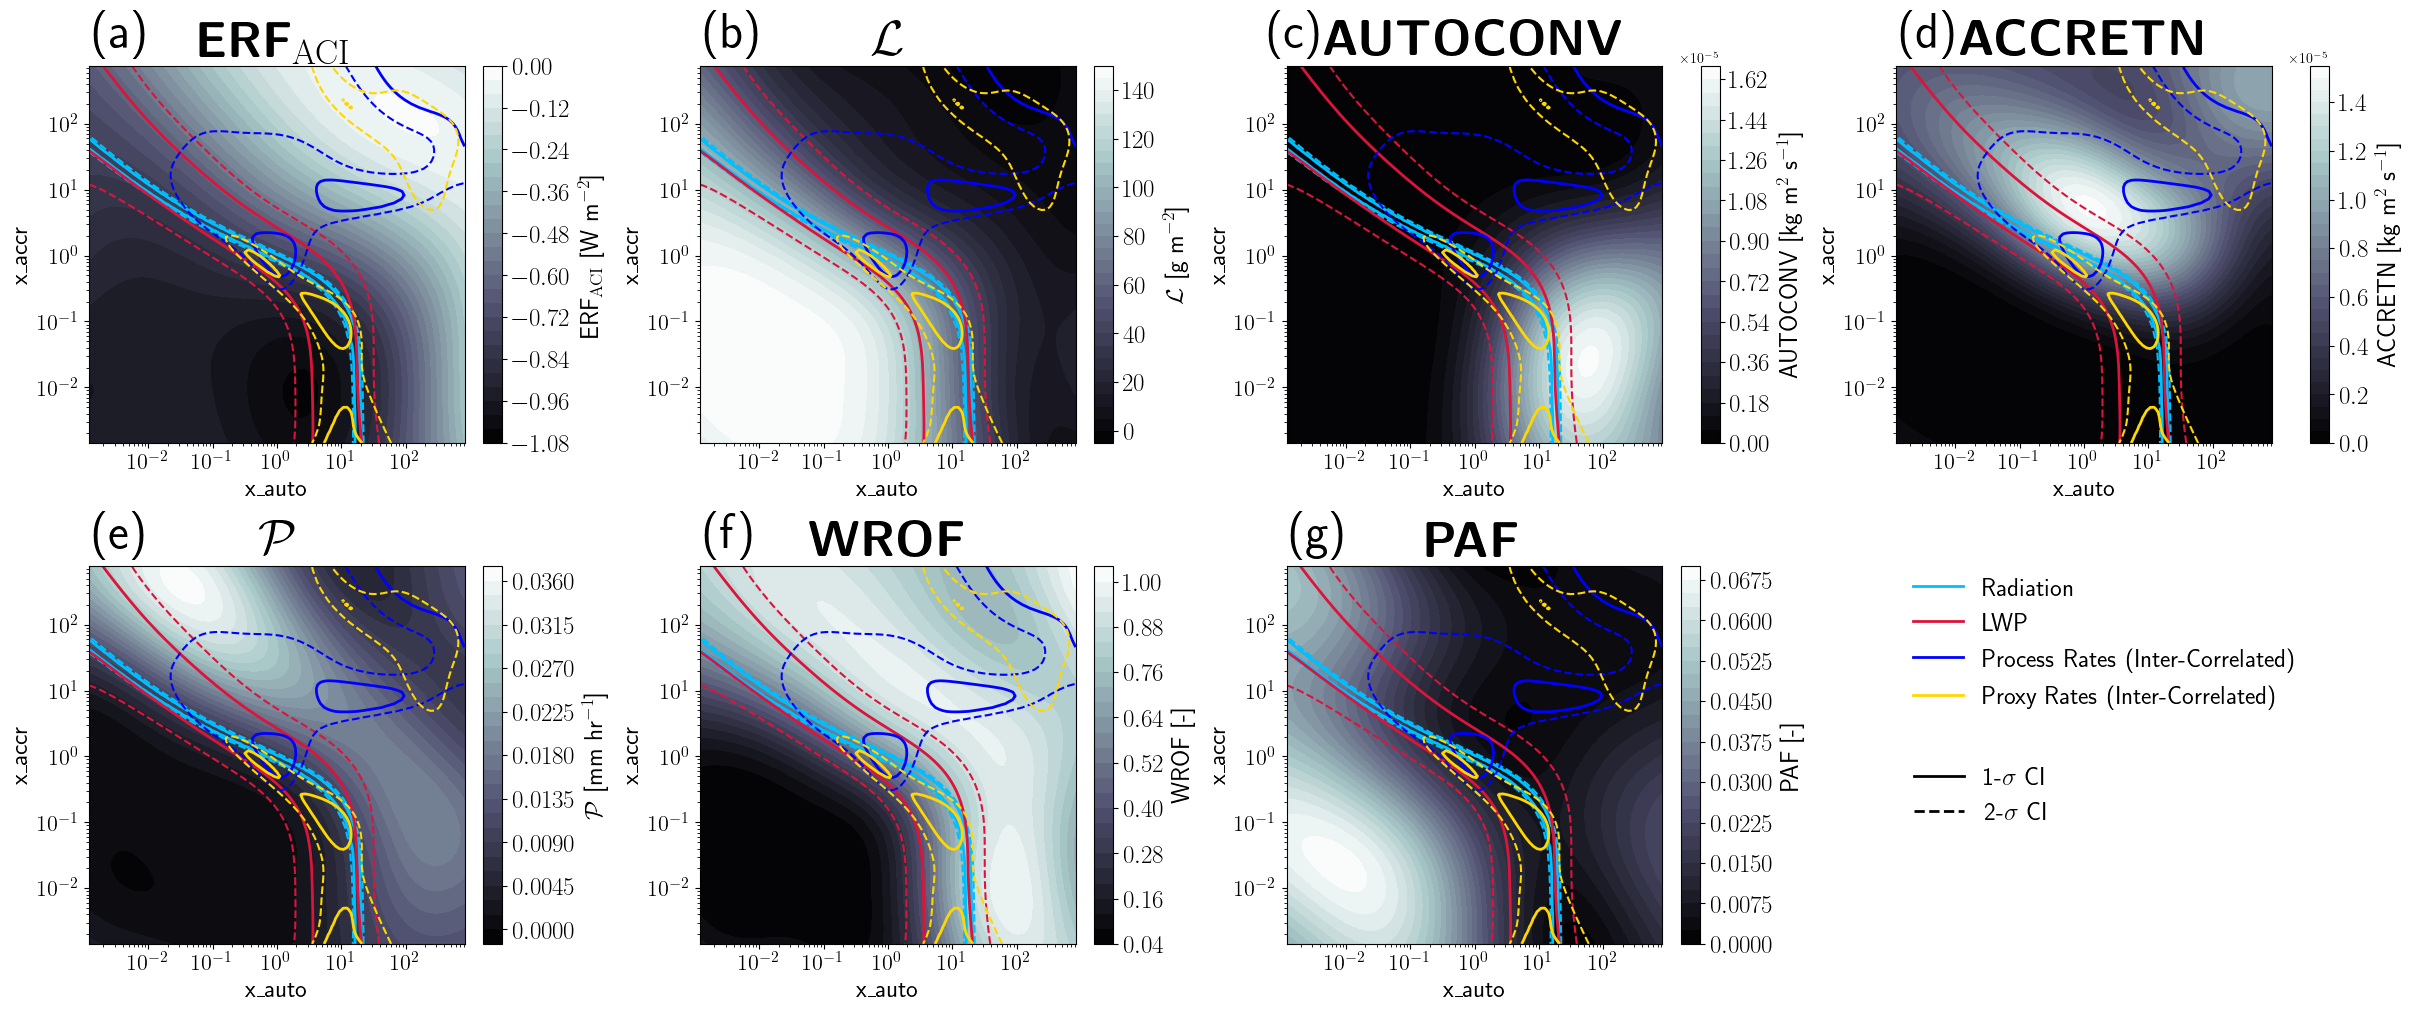

In [53]:

# --- 2. PLOTTING THE 3x4 FIGURE ---
fig, axes = plt.subplots(2, 4, figsize=(24, 10), constrained_layout=True)
axes_flat = np.ndarray.flatten(axes)
Fontsize = 18

plot_vars = ['ERF_ACI','LWP_PD', 'AUTOCONV_PD','ACCRETN_PD','PRECL_PD', 'WROF_PD', 'PAF_PD']
cbar_labs = ['ERF$_{\mathrm{ACI}}$ [W m$^{-2}$]','$\mathcal{L}$ [g m$^{-2}$]',\
             'AUTOCONV [kg m$^{2}$ s$^{-1}$]','ACCRETN [kg m$^{2}$ s$^{-1}$]',\
             '$\mathcal{P}$ [mm hr$^{-1}$]','WROF [-]','PAF [-]']
titles = [r'\textbf{ERF$_{\mathrm{ACI}}$}',r'\textbf{$\mathcal{L}$}',\
          r'\textbf{AUTOCONV}',r'\textbf{ACCRETN}',\
          r'\textbf{$\mathcal{P}$}',r'\textbf{WROF}',r'\textbf{PAF}']
confidence_delta_ll = [-3.09, -1.15] # 95% and 68% CIs

# Calculate Rad-only contour levels once
max_like_rad = np.nanmax(likelihood_surfaces['Rad_only'])
contour_levels_rad = max_like_rad + np.array(confidence_delta_ll)
labs = ['(a)','(b)','(c)','(d)','(e)','(f)','(g)']
for i, var_name in enumerate(plot_vars):
    ax = axes_flat[i]
        
    surface_to_plot = prediction_surfaces[var_name]
    cf = ax.contourf(x_auto_physical, x_accr_physical, surface_to_plot, levels=30, cmap='bone')
    cbar = fig.colorbar(cf, ax=ax)
    cbar.ax.set_ylabel(cbar_labs[i], fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    # --- OVERLAY ALL THREE CONTOUR SETS ---

    if True:
        # 1. Rad-only 
        ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces['Rad_only'], levels=contour_levels_rad, colors='deepskyblue', linewidths=[1.5, 2.0], linestyles=['dashed', 'solid'])
    
        # 2. LWP-only 
        lwp_key = f'LWP_only_{int(err_frac*100)}'
        max_like_lwp = np.nanmax(likelihood_surfaces[lwp_key])
        contour_levels_lwp = max_like_lwp + np.array(confidence_delta_ll)
        ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces[lwp_key], levels=contour_levels_lwp, colors='crimson', linewidths=[1.5, 2.0], linestyles=['dashed', 'solid'])
       
        # 3. Process-only 
        proc_key = f'Proc_only_{int(err_frac*100)}'
        max_like_proc = np.nanmax(likelihood_surfaces[proc_key])
        contour_levels_proc = max_like_proc + np.array(confidence_delta_ll)
        ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces[proc_key], levels=contour_levels_proc, colors='blue', linewidths=[1.5, 2.0], linestyles=['dashed', 'solid'])
        
        # 4. Proxy-only 
        prox_key = f'Prox_only_{int(err_frac*100)}'
        max_like_prox = np.nanmax(likelihood_surfaces[prox_key])
        contour_levels_prox = max_like_prox + np.array(confidence_delta_ll)
        ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces[prox_key], levels=contour_levels_prox, colors='gold', linewidths=[1.5, 2.0], linestyles=['dashed', 'solid'])
        
    # --- FORMATTING ---
    ax.set_title(titles[i], fontsize=Fontsize*2.)
    if var_name != 'AUTOCONV_PD':
        ax.text(0.01,1.05,labs[i],fontsize=Fontsize*2.,ha='left',transform=ax.transAxes)
    else:
        ax.text(-0.05,1.05,labs[i],fontsize=Fontsize*2.,ha='left',transform=ax.transAxes)
        
    #if i == 0:
    #    dum_str = f'Obs Error: {int(err_frac*100.)}\%'
    #    dum_str = rf'\textbf{{{dum_str}}}'
    #    ax.text(-0.35, 0.5, dum_str, ha='center', va='center', transform=ax.transAxes, rotation=90, fontsize=Fontsize*1.5)
    
    ax.set_xlabel("x_auto", fontsize=Fontsize)
    ax.set_ylabel("x_accr", fontsize=Fontsize)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.tick_params(labelsize=Fontsize - 2)

# Create a single legend for the whole figure
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='deepskyblue', lw=2, label='Radiation'),
    Line2D([0], [0], color='crimson', lw=2, label='LWP'),
    Line2D([0], [0], color='blue', lw=2, label='Process Rates (Inter-Correlated)'),
    Line2D([0], [0], color='gold', lw=2, label='Proxy Rates (Inter-Correlated)'),
]
legend_elements2 = [
    Line2D([0], [0], color='k', lw=2, label='1-$\sigma$ CI'),
    Line2D([0], [0], color='k', lw=2, ls='dashed',label='2-$\sigma$ CI'),
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.875, 0.45), ncol=1, fontsize=Fontsize,framealpha=False)
fig.legend(handles=legend_elements2, loc='upper center', bbox_to_anchor=(0.823, 0.26), ncol=1, fontsize=Fontsize,framealpha=False)

axes_flat[-1].set_axis_off()

plt.show()
plt.close()

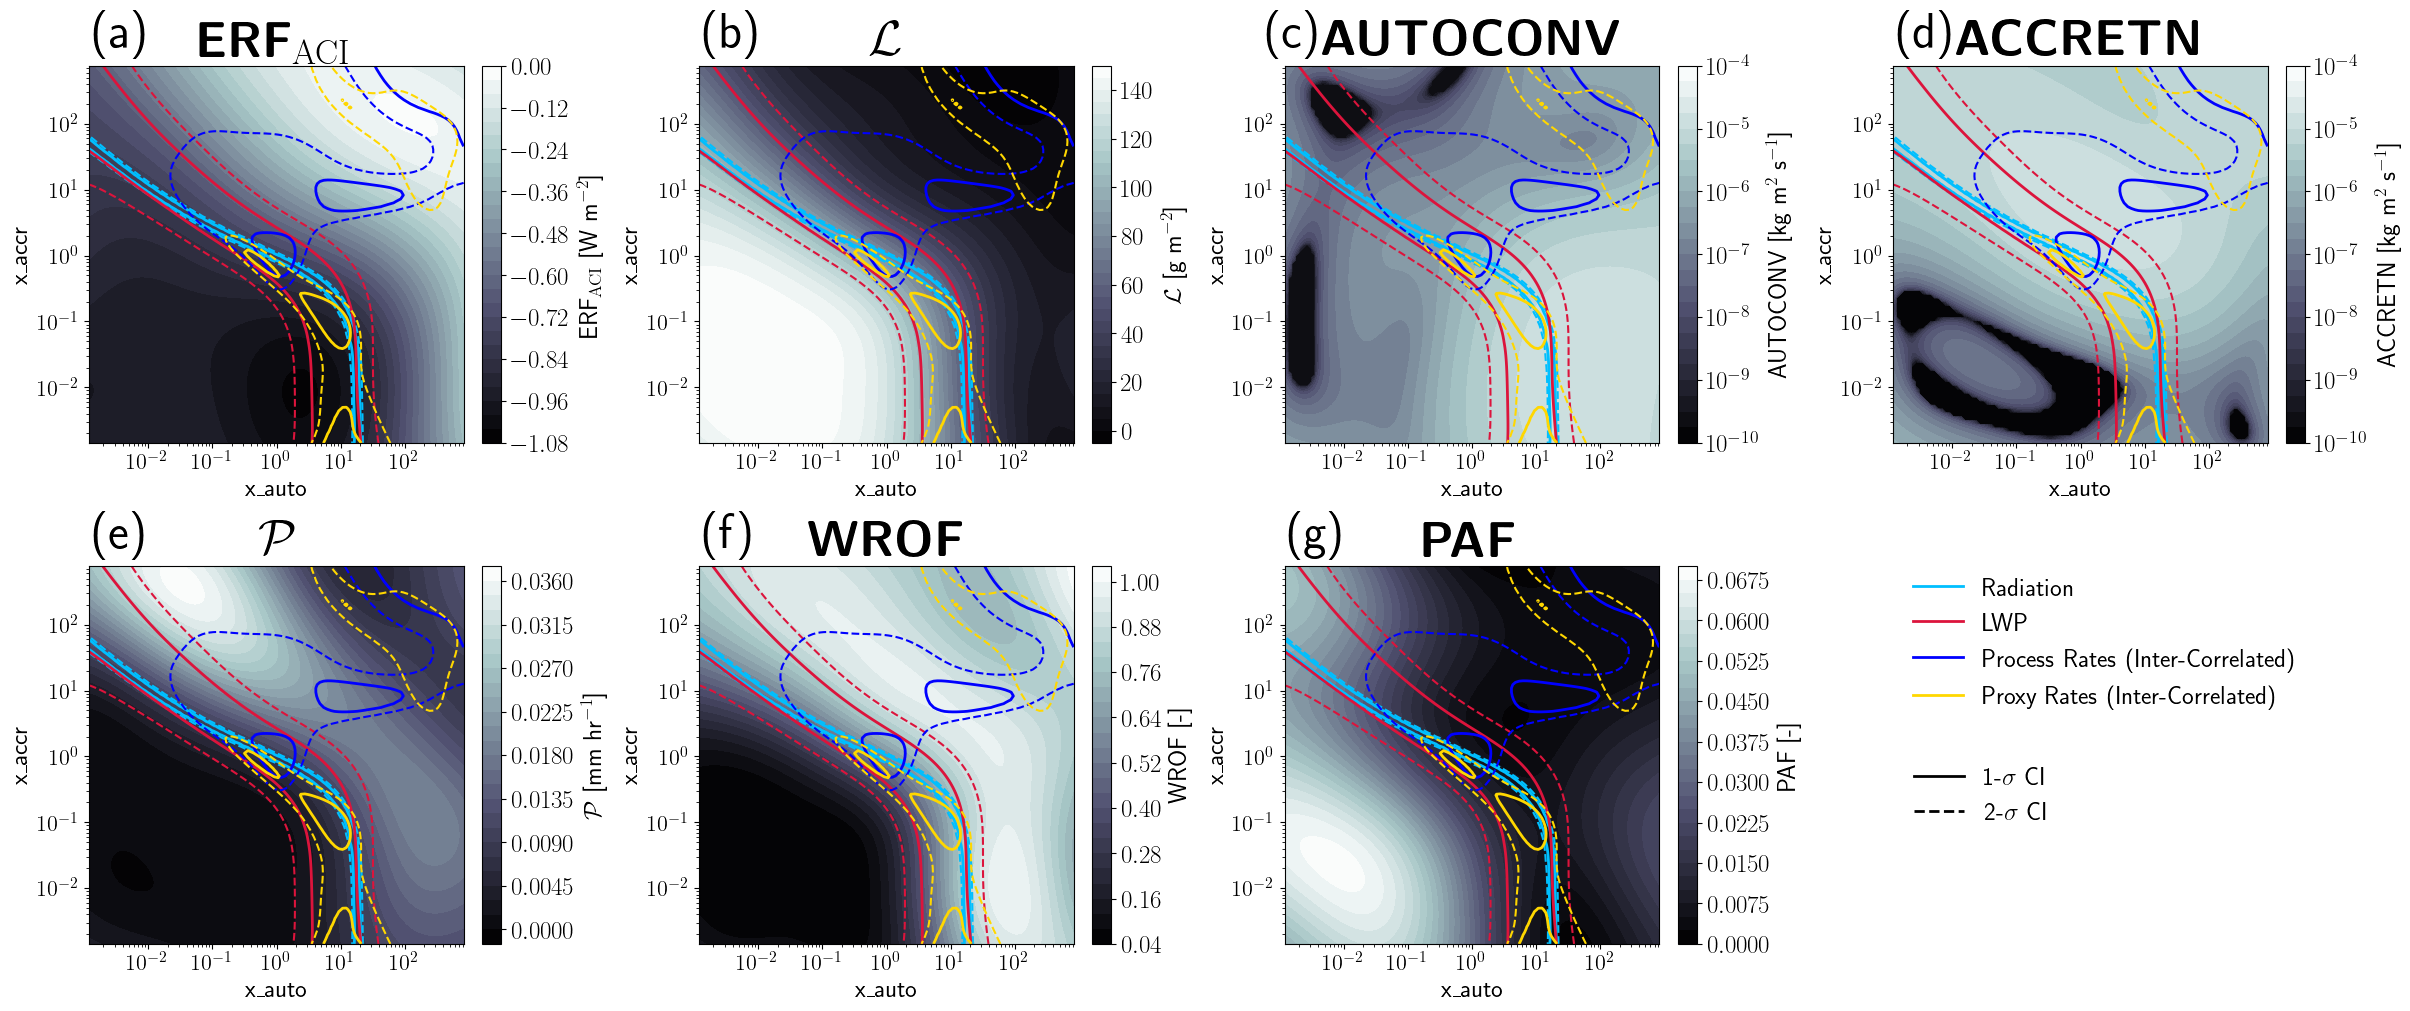

In [54]:

# --- 2. PLOTTING THE 3x4 FIGURE ---
fig, axes = plt.subplots(2, 4, figsize=(24, 10), constrained_layout=True)
axes_flat = np.ndarray.flatten(axes)
Fontsize = 18

plot_vars = ['ERF_ACI','LWP_PD', 'AUTOCONV_PD','ACCRETN_PD','PRECL_PD', 'WROF_PD', 'PAF_PD']
cbar_labs = ['ERF$_{\mathrm{ACI}}$ [W m$^{-2}$]','$\mathcal{L}$ [g m$^{-2}$]',\
             'AUTOCONV [kg m$^{2}$ s$^{-1}$]','ACCRETN [kg m$^{2}$ s$^{-1}$]',\
             '$\mathcal{P}$ [mm hr$^{-1}$]','WROF [-]','PAF [-]']
titles = [r'\textbf{ERF$_{\mathrm{ACI}}$}',r'\textbf{$\mathcal{L}$}',\
          r'\textbf{AUTOCONV}',r'\textbf{ACCRETN}',\
          r'\textbf{$\mathcal{P}$}',r'\textbf{WROF}',r'\textbf{PAF}']
confidence_delta_ll = [-3.09, -1.15] # 95% and 68% CIs

# Calculate Rad-only contour levels once
max_like_rad = np.nanmax(likelihood_surfaces['Rad_only'])
contour_levels_rad = max_like_rad + np.array(confidence_delta_ll)
labs = ['(a)','(b)','(c)','(d)','(e)','(f)','(g)']

for i, var_name in enumerate(plot_vars):
    ax = axes_flat[i]
    
    surface_to_plot = prediction_surfaces[var_name]

    levels = 10.**(np.arange(-10,-3.75,0.25))
    ticks = 10.**(np.arange(-10,-3,1))
    if var_name in ['AUTOCONV_PD','ACCRETN_PD']:
        cf = ax.contourf(x_auto_physical, x_accr_physical, surface_to_plot, levels=levels, cmap='bone',norm=mpl.colors.LogNorm())
        cbar = fig.colorbar(cf, ax=ax)
        cbar.ax.set_ylabel(cbar_labs[i], fontsize=Fontsize)
        cbar.ax.tick_params(labelsize=Fontsize)
        cbar.ax.set_yticks(ticks)
    else:
        cf = ax.contourf(x_auto_physical, x_accr_physical, surface_to_plot, levels=30, cmap='bone')
        cbar = fig.colorbar(cf, ax=ax)
        cbar.ax.set_ylabel(cbar_labs[i], fontsize=Fontsize)
        cbar.ax.tick_params(labelsize=Fontsize)
    # --- OVERLAY ALL THREE CONTOUR SETS ---

    if True:
        # 1. Rad-only 
        ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces['Rad_only'], levels=contour_levels_rad, colors='deepskyblue', linewidths=[1.5, 2.0], linestyles=['dashed', 'solid'])
    
        # 2. LWP-only 
        lwp_key = f'LWP_only_{int(err_frac*100)}'
        max_like_lwp = np.nanmax(likelihood_surfaces[lwp_key])
        contour_levels_lwp = max_like_lwp + np.array(confidence_delta_ll)
        ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces[lwp_key], levels=contour_levels_lwp, colors='crimson', linewidths=[1.5, 2.0], linestyles=['dashed', 'solid'])
       
        # 3. Process-only 
        proc_key = f'Proc_only_{int(err_frac*100)}'
        max_like_proc = np.nanmax(likelihood_surfaces[proc_key])
        contour_levels_proc = max_like_proc + np.array(confidence_delta_ll)
        ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces[proc_key], levels=contour_levels_proc, colors='blue', linewidths=[1.5, 2.0], linestyles=['dashed', 'solid'])
        
        # 4. Proxy-only 
        prox_key = f'Prox_only_{int(err_frac*100)}'
        max_like_prox = np.nanmax(likelihood_surfaces[prox_key])
        contour_levels_prox = max_like_prox + np.array(confidence_delta_ll)
        ax.contour(x_auto_physical, x_accr_physical, likelihood_surfaces[prox_key], levels=contour_levels_prox, colors='gold', linewidths=[1.5, 2.0], linestyles=['dashed', 'solid'])
        
    # --- FORMATTING ---
    ax.set_title(titles[i], fontsize=Fontsize*2.)
    if var_name != 'AUTOCONV_PD':
        ax.text(0.01,1.05,labs[i],fontsize=Fontsize*2.,ha='left',transform=ax.transAxes)
    else:
        ax.text(-0.05,1.05,labs[i],fontsize=Fontsize*2.,ha='left',transform=ax.transAxes)
    #if i == 0:
    #    dum_str = f'Obs Error: {int(err_frac*100.)}\%'
    #    dum_str = rf'\textbf{{{dum_str}}}'
    #    ax.text(-0.35, 0.5, dum_str, ha='center', va='center', transform=ax.transAxes, rotation=90, fontsize=Fontsize*1.5)
    
    ax.set_xlabel("x_auto", fontsize=Fontsize)
    ax.set_ylabel("x_accr", fontsize=Fontsize)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.tick_params(labelsize=Fontsize - 2)

# Create a single legend for the whole figure
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='deepskyblue', lw=2, label='Radiation'),
    Line2D([0], [0], color='crimson', lw=2, label='LWP'),
    Line2D([0], [0], color='blue', lw=2, label='Process Rates (Inter-Correlated)'),
    Line2D([0], [0], color='gold', lw=2, label='Proxy Rates (Inter-Correlated)'),
]
legend_elements2 = [
    Line2D([0], [0], color='k', lw=2, label='1-$\sigma$ CI'),
    Line2D([0], [0], color='k', lw=2, ls='dashed',label='2-$\sigma$ CI'),
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.875, 0.45), ncol=1, fontsize=Fontsize,framealpha=False)
fig.legend(handles=legend_elements2, loc='upper center', bbox_to_anchor=(0.823, 0.26), ncol=1, fontsize=Fontsize,framealpha=False)

axes_flat[-1].set_axis_off()

plt.show()
plt.close()

In [39]:
levels

array([1.00000000e-10, 1.77827941e-10, 3.16227766e-10, 5.62341325e-10,
       1.00000000e-09, 1.77827941e-09, 3.16227766e-09, 5.62341325e-09,
       1.00000000e-08, 1.77827941e-08, 3.16227766e-08, 5.62341325e-08,
       1.00000000e-07, 1.77827941e-07, 3.16227766e-07, 5.62341325e-07,
       1.00000000e-06, 1.77827941e-06, 3.16227766e-06, 5.62341325e-06,
       1.00000000e-05, 1.77827941e-05, 3.16227766e-05, 5.62341325e-05,
       1.00000000e-04])

# Load data

In [11]:
# --- Load Data  ---
exp_name = 'OLR_OSR_UniformPrior_CovCloud_Correlated_withGPerr'
with open(f'./mcmc_plot_data_v4/plot_data_{exp_name}_impact_thin.pkl', "rb") as file:
    plot_data_rad = pickle.load(file)
    
exp_name = 'OLR_OSR_Plus_LWP_UniformPrior_CovCloud_Correlated_withGPerr'
with open(f'./mcmc_plot_data_v4/plot_data_{exp_name}_impact_thin.pkl', "rb") as file:
    plot_data_rad_lwp = pickle.load(file)
    
exp_name = 'OLR_OSR_Plus_LWP_AUTOCONV_ACCRETN_UniformPrior_CovCloud_Correlated_withGPerr'
with open(f'./mcmc_plot_data_v4/plot_data_{exp_name}_impact_thin.pkl', "rb") as file:
    plot_data_rad_lwp_proc = pickle.load(file)
    
exp_name = 'OLR_OSR_Plus_LWP_PRECL_WROF_PAF_UniformPrior_CovCloud_Correlated_withGPerr'
with open(f'./mcmc_plot_data_v4/plot_data_{exp_name}_impact_thin.pkl', "rb") as file:
    plot_data_rad_lwp_prox = pickle.load(file)
    
exp_name = 'OLR_OSR_Plus_LWP_LWP20PercErr_UniformPrior_CovCloud_Correlated_withGPerr'
with open(f'./mcmc_plot_data_v4/plot_data_{exp_name}_impact_thin.pkl', "rb") as file:
    plot_data_rad_lwp_20pc = pickle.load(file)

exp_name = 'OLR_OSR_Plus_LWP_AUTOCONV_ACCRETN_Cloud20PercErr_UniformPrior_CovCloud_Correlated_withGPerr'
with open(f'./mcmc_plot_data_v4/plot_data_{exp_name}_impact_thin.pkl', "rb") as file:
    plot_data_rad_lwp_proc_20pc = pickle.load(file)

exp_name = 'OLR_OSR_Plus_LWP_PRECL_WROF_PAF_Cloud20PercErr_UniformPrior_CovCloud_Correlated_withGPerr'
with open(f'./mcmc_plot_data_v4/plot_data_{exp_name}_impact_thin.pkl', "rb") as file:
    plot_data_rad_lwp_prox_20pc = pickle.load(file)

exp_name = 'OLR_OSR_Plus_LWP_LWP50PercErr_UniformPrior_CovCloud_Correlated_withGPerr'
with open(f'./mcmc_plot_data_v4/plot_data_{exp_name}_impact_thin.pkl', "rb") as file:
    plot_data_rad_lwp_50pc = pickle.load(file)

exp_name = 'OLR_OSR_Plus_LWP_AUTOCONV_ACCRETN_Cloud50PercErr_UniformPrior_CovCloud_Correlated_withGPerr'
with open(f'./mcmc_plot_data_v4/plot_data_{exp_name}_impact_thin.pkl', "rb") as file:
    plot_data_rad_lwp_proc_50pc = pickle.load(file)

exp_name = 'OLR_OSR_Plus_LWP_PRECL_WROF_PAF_Cloud50PercErr_UniformPrior_CovCloud_Correlated_withGPerr'
with open(f'./mcmc_plot_data_v4/plot_data_{exp_name}_impact_thin.pkl', "rb") as file:
    plot_data_rad_lwp_prox_50pc = pickle.load(file)

exp_name = 'OLR_OSR_Plus_LWP_PRECL_UniformPrior_CovCloud_Correlated_withGPerr'
with open(f'./mcmc_plot_data_v4/plot_data_{exp_name}_impact_thin.pkl', "rb") as file:
    plot_data_rad_lwp_precl = pickle.load(file)

exp_name = 'OLR_OSR_Plus_LWP_PRECL_Cloud20PercErr_UniformPrior_CovCloud_Correlated_withGPerr'
with open(f'./mcmc_plot_data_v4/plot_data_{exp_name}_impact_thin.pkl', "rb") as file:
    plot_data_rad_lwp_precl_20pc = pickle.load(file)

exp_name = 'OLR_OSR_Plus_LWP_PRECL_Cloud50PercErr_UniformPrior_CovCloud_Correlated_withGPerr'
with open(f'./mcmc_plot_data_v4/plot_data_{exp_name}_impact_thin.pkl', "rb") as file:
    plot_data_rad_lwp_precl_50pc = pickle.load(file)

In [42]:
use_dict = plot_data_rad_lwp_50pc['posteriors'].copy()
use_dict['x_auto'] = use_dict['inputs']['x_auto']
use_dict['x_accr'] = use_dict['inputs']['x_accr']
del use_dict['inputs']
print(use_dict.keys())
use_df = pd.DataFrame(use_dict)

dict_keys(['OSR_UPWELL_PD', 'OLR_UPWELL_PD', 'CRF_SW_PD', 'CRF_LW_PD', 'RESTOM_PD', 'ERF_ACI', 'LWP_PD', 'LWP_adj', 'CDNC_PD', 'CDNC_adj', 'REFF_PD', 'REFF_adj', 'GLOBAL_LCC_PD', 'GLOBAL_LCC_adj', 'PRECL_PD', 'PRECL_adj', 'WROF_PD', 'WROF_adj', 'PAF_PD', 'PAF_adj', 'AUTOCONV_PD', 'AUTOCONV_adj', 'ACCRETN_PD', 'ACCRETN_adj', 'x_auto', 'x_accr'])


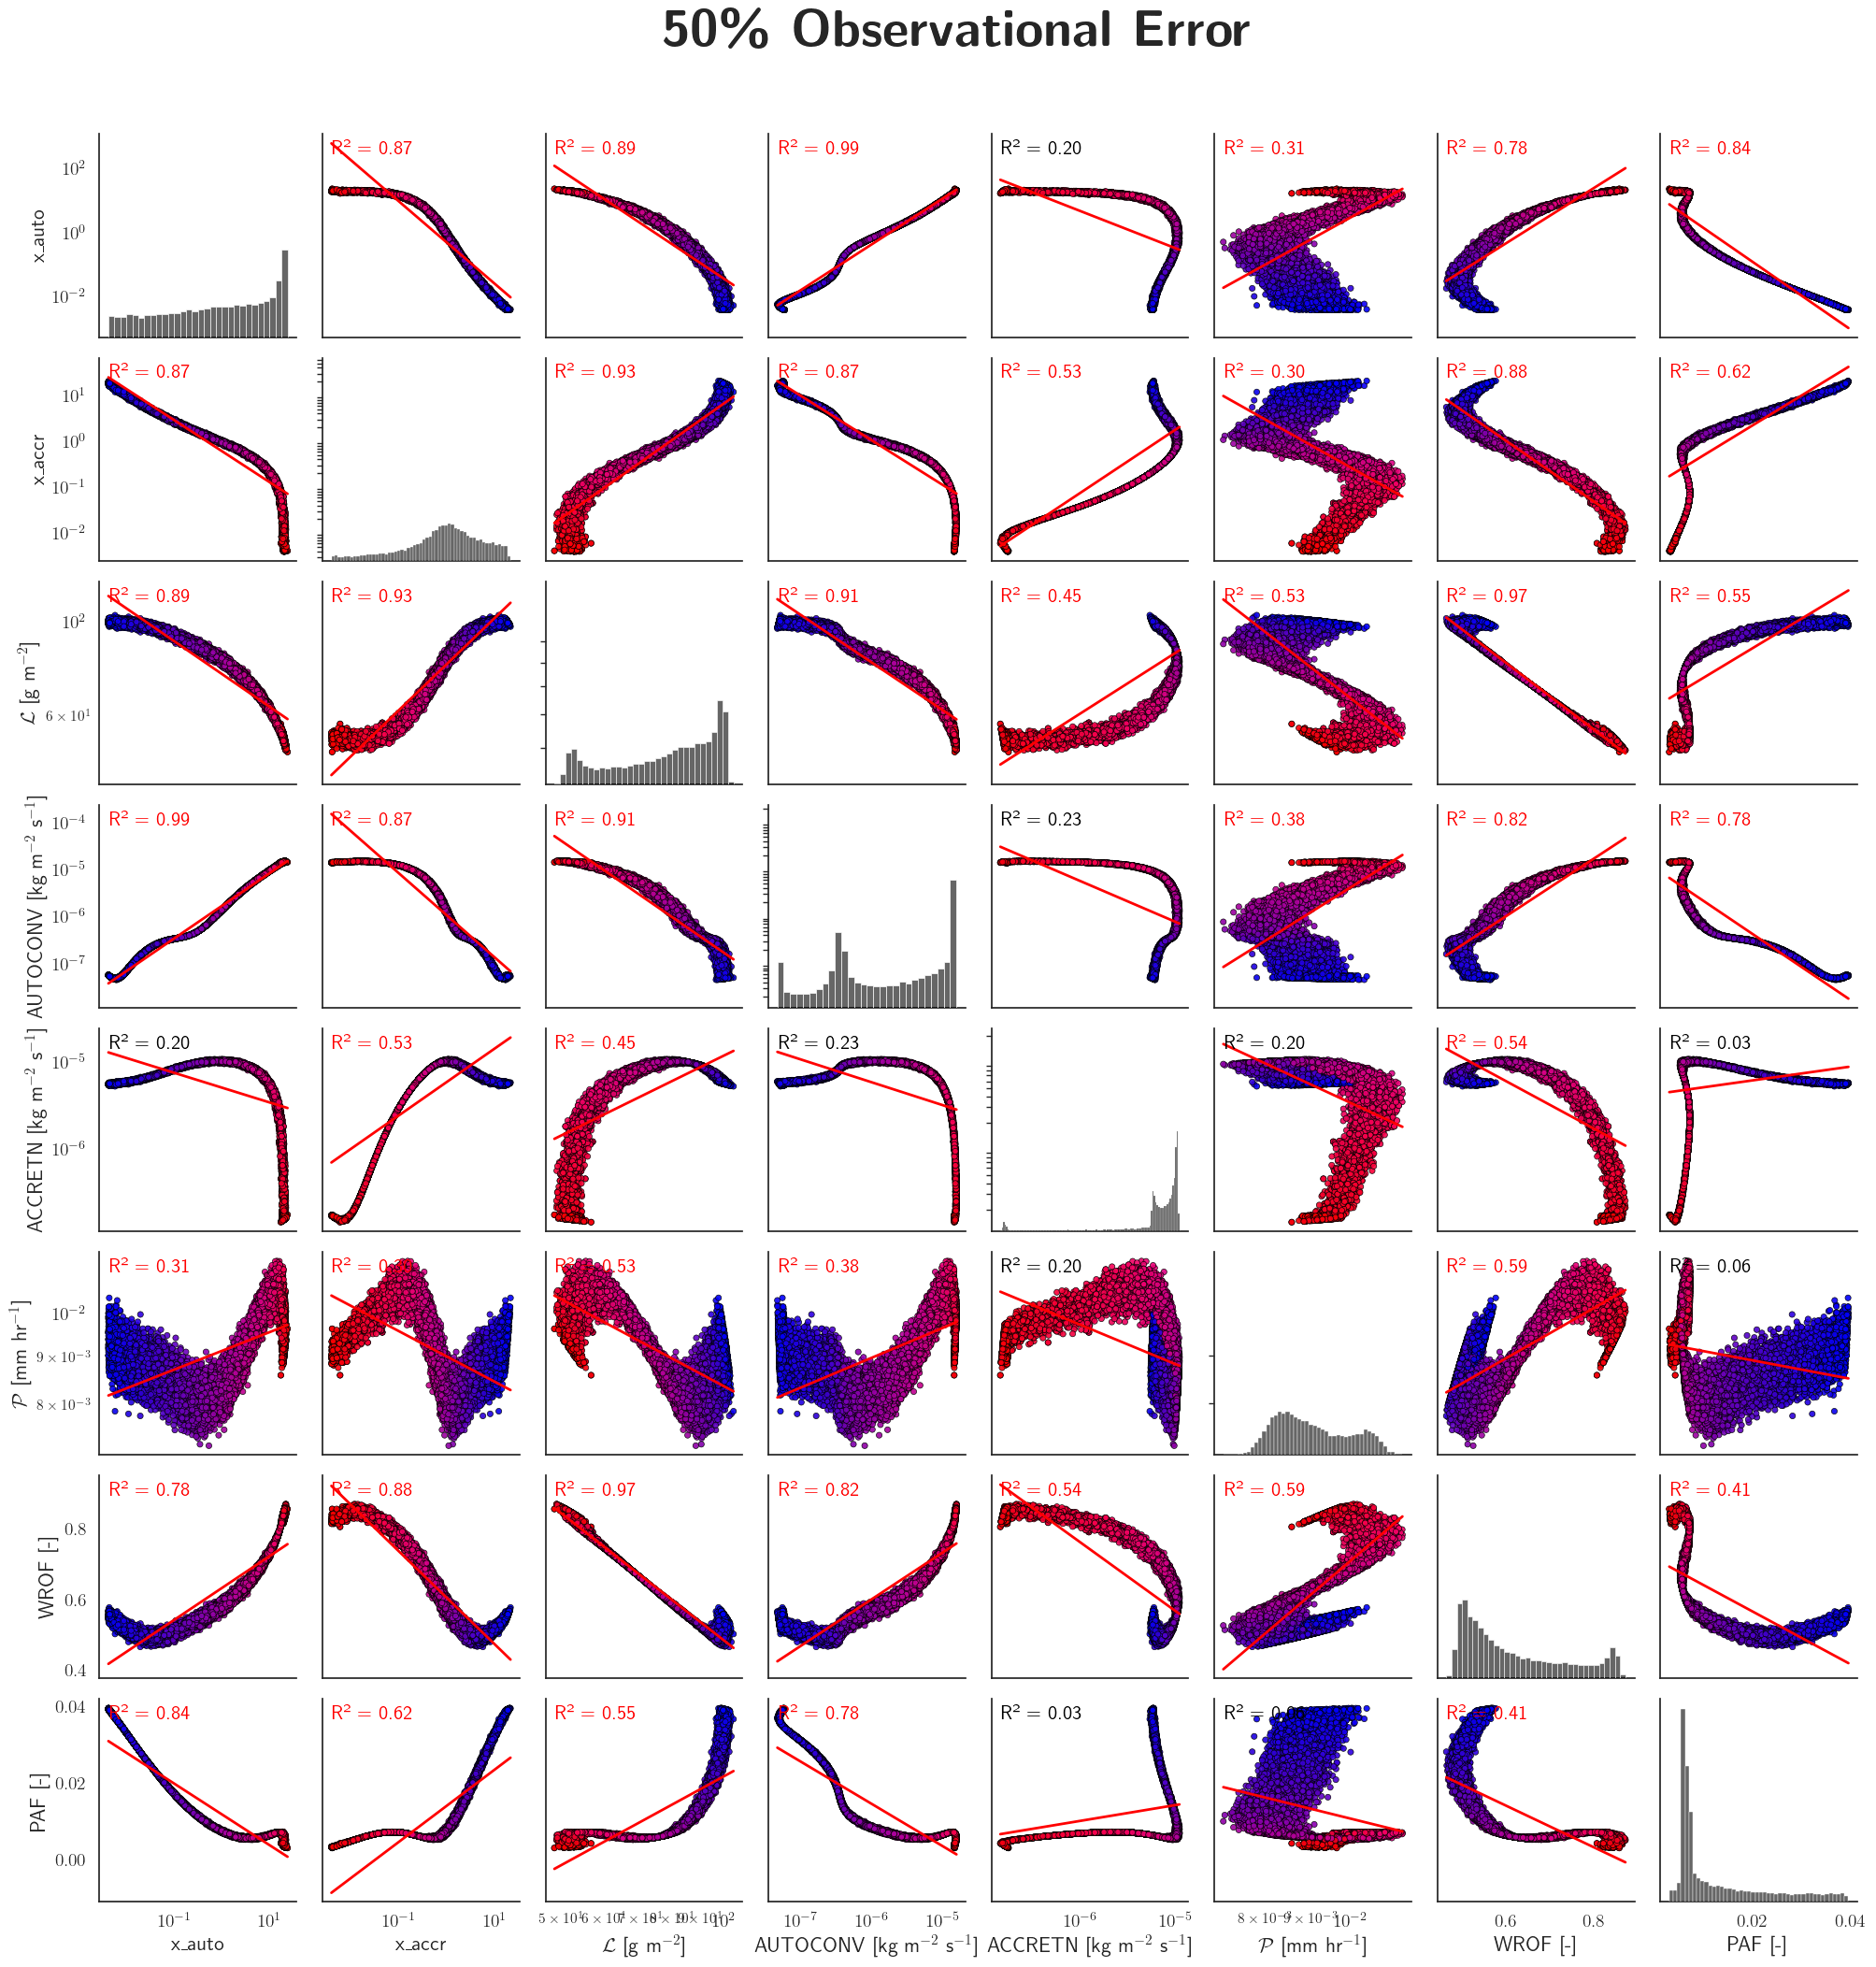

done


In [46]:

# --- This script assumes your 'df_regime2' DataFrame is already loaded ---

# --- Set a nice plot style ---
sns.set_theme(style="white")
Fontsize = 16

# --- 1. PRE-CALCULATE THE BIVARIATE COLORS ---
x_min, x_max = use_df['x_auto'].min(), use_df['x_auto'].max()
y_min, y_max = use_df['x_accr'].min(), use_df['x_accr'].max()

x_scaler = MinMaxScaler().fit(np.log10([[x_min], [x_max]]))
y_scaler = MinMaxScaler().fit(np.log10([[y_min], [y_max]]))

def get_bivariate_colors(x_data, y_data, x_scaler_fit, y_scaler_fit):
    log_x = np.log10(np.asarray(x_data))
    log_y = np.log10(np.asarray(y_data))
    
    red_channel = x_scaler_fit.transform(log_x.flatten().reshape(-1, 1)).flatten()
    blue_channel = y_scaler_fit.transform(log_y.flatten().reshape(-1, 1)).flatten()
    green_channel = np.zeros_like(red_channel)
    
    return np.stack([red_channel, green_channel, blue_channel], axis=1)

colors_for_plot = get_bivariate_colors(use_df['x_auto'], use_df['x_accr'], x_scaler, y_scaler)

# --- 2. Define variables and labels ---
pairplot_vars = ['x_auto', 'x_accr','LWP_PD','AUTOCONV_PD','ACCRETN_PD','PRECL_PD','WROF_PD','PAF_PD']
log_vars = ['x_auto', 'x_accr','AUTOCONV_PD','ACCRETN_PD','LWP_PD','PRECL_PD']
label_map = {
    'x_auto': 'x_auto', 'x_accr': 'x_accr',
    'LWP_PD': r'$\mathcal{L}$ [g m$^{-2}$]',
    'AUTOCONV_PD':'AUTOCONV [kg m$^{-2}$ s$^{-1}$]',
    'ACCRETN_PD':'ACCRETN [kg m$^{-2}$ s$^{-1}$]',
    'PRECL_PD':r'$\mathcal{P}$ [mm hr$^{-1}$]',
    'WROF_PD': 'WROF [-]', 'PAF_PD': 'PAF [-]',
}

# --- 3. Create the PairGrid object WITHOUT hue/palette ---
g = sns.PairGrid(use_df[pairplot_vars], height=2.5)

# --- 4. Map histograms to the diagonal ---
def hist_with_log(x, **kwargs):
    if x.name in log_vars:
        sns.histplot(x, log_scale=True, **kwargs)
    else:
        sns.histplot(x, **kwargs)
g.map_diag(hist_with_log, color='black', alpha=0.6)

# --- 5. Create our MODIFIED plotting function ---
# The key change is that this function no longer relies on 'hue'.
# It directly accepts our list of colors.
def scatter_and_manual_reg_line(x, y, colors=None, **kwargs):
    ax = plt.gca()
    x_var_name = x.name
    y_var_name = y.name
    
    # Step A: Draw the scatter plot using the 'c' argument
    ax.scatter(x=x, y=y, c=colors, s=20, alpha=0.9, edgecolor='black', linewidth=0.5)
    
    # Step B: Manually set axis scales
    log_x = x_var_name in log_vars
    log_y = y_var_name in log_vars
    if log_x: ax.set_xscale('log')
    if log_y: ax.set_yscale('log')
        
    # Step C: Calculate regression
    x_for_corr = np.log10(x) if log_x else x
    y_for_corr = np.log10(y) if log_y else y
    slope, intercept, r_value, _, _ = linregress(x_for_corr, y_for_corr)
    r_squared = r_value**2
    
    # Step D: Manually plot regression line
    x_line = np.linspace(x.min(), x.max(), 100)
    x_line_transformed = np.log10(x_line) if log_x else x_line
    y_line_transformed = slope * x_line_transformed + intercept
    y_line_final = 10**y_line_transformed if log_y else y_line_transformed
    ax.plot(x_line, y_line_final, color='red', linewidth=2)
    
    # Step E: Annotate with R-squared
    font_color = 'red' if r_squared > 0.3 else 'black'
    ax.text(0.05, 0.90, f'R² = {r_squared:.2f}',
            transform=ax.transAxes, fontsize=Fontsize-1,
            fontweight='bold', color=font_color)

# --- Map the function, passing our colors as a keyword argument ---
g.map_offdiag(scatter_and_manual_reg_line, colors=colors_for_plot)

# --- 6. Set axis labels (Unchanged) ---
num_vars = len(pairplot_vars)
for i in range(num_vars):
    for j in range(num_vars):
        ax = g.axes[i, j]
        if i == num_vars - 1:
            ax.set_xlabel(label_map[pairplot_vars[j]], fontsize=Fontsize)
        if j == 0:
            ax.set_ylabel(label_map[pairplot_vars[i]], fontsize=Fontsize)

g.tick_params(labelsize=Fontsize-2)


plt.suptitle(r'\textbf{50\% Observational Error}',fontsize=Fontsize*2.5,y=1.05)

plt.show()
plt.close()
print('done')

--- Loading data from pickle file ---
--- Building DataFrames ---
DataFrames are ready.
--- Creating Plot ---


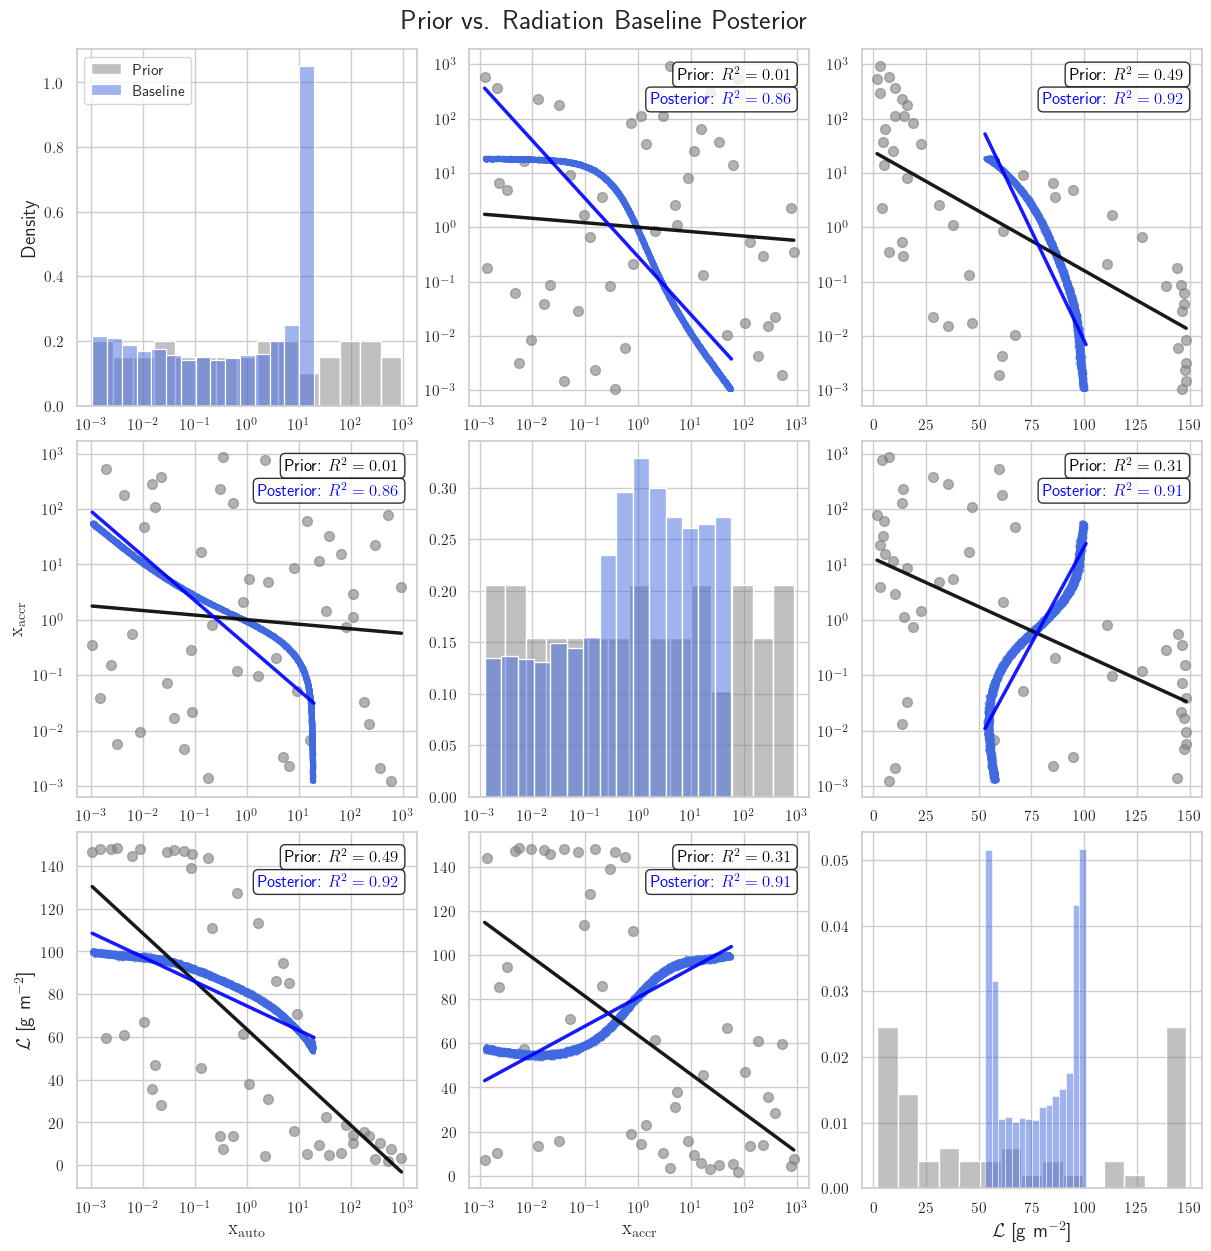

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import joblib
from scipy.stats import linregress

# ==============================================================================
# 1. LOAD DATA
# ==============================================================================
print("--- Loading data from pickle file ---")
thin_bool = True
exp_baseline = 'Radiation_Baseline'
# Load the single dictionary we need
baseline_filename = f'./mcmc_plot_data/plot_data_{exp_baseline}_impact_{"thin" if thin_bool else "nothin"}.pkl'
with open(baseline_filename, "rb") as file:
    plot_data_baseline = pickle.load(file)
# The Prior is your original 50-member ensemble DataFrame
df_prior = df_regime2.copy()

# ==============================================================================
# 2. EXTRACT DATA AND CREATE DATAFRAMES
# ==============================================================================
print("--- Building DataFrames ---")
plot_vars = ['x_auto', 'x_accr', 'LWP_PD']
log_vars_set = {'x_auto', 'x_accr'}
posterior_data = {
    'x_auto': plot_data_baseline['posteriors']['inputs']['x_auto'],
    'x_accr': plot_data_baseline['posteriors']['inputs']['x_accr'],
    'LWP_PD': plot_data_baseline['posteriors']['LWP_PD']
}

# --- THIS IS THE ONLY CHANGE (Adding the labels dictionary) ---
labels = {
    'x_auto': r'$\mathrm{x_{auto}}$',
    'x_accr': r'$\mathrm{x_{accr}}$',
    'LWP_PD': r'$\mathcal{L}$ [g m$^{-2}$]',
}
# -------------------------------------------------------------

df_baseline = pd.DataFrame(posterior_data)
n_plot_samples = len(df_baseline) # Use all samples as requested
if len(df_baseline) > n_plot_samples:
    df_baseline_sample = df_baseline.sample(n=n_plot_samples, random_state=42)
else:
    df_baseline_sample = df_baseline
print("DataFrames are ready.")

# ==============================================================================
# 3. CREATE THE PAIR PLOT MANUALLY
# ==============================================================================
print("--- Creating Plot ---")
num_vars = len(plot_vars)
fig, axes = plt.subplots(num_vars, num_vars, figsize=(12, 12), constrained_layout=True)
fig.suptitle("Prior vs. Radiation Baseline Posterior", y=1.03, fontsize=20)
Fontsize = 14

for i in range(num_vars):
    for j in range(num_vars):
        ax = axes[i, j]
        x_name = plot_vars[j]
        y_name = plot_vars[i]
        is_log_x = x_name in log_vars_set
        is_log_y = y_name in log_vars_set
        
        # --- DIAGONAL PLOTS (HISTOGRAMS) ---
        if i == j:
            sns.histplot(data=df_prior, x=x_name, ax=ax, stat='density', color='gray', alpha=0.5, log_scale=is_log_x, label='Prior', bins=15)
            sns.histplot(data=df_baseline_sample, x=x_name, ax=ax, stat='density', color='royalblue', alpha=0.5, log_scale=is_log_x, label='Baseline', bins=15)
            if i == 0:
                ax.legend()
        
        # --- OFF-DIAGONAL PLOTS (SCATTERS) ---
        else:
            ax.scatter(df_prior[x_name], df_prior[y_name], color='gray', s=50, alpha=0.6)
            ax.scatter(df_baseline_sample[x_name], df_baseline_sample[y_name], color='royalblue', s=5, alpha=0.4)
            if is_log_x: ax.set_xscale('log')
            if is_log_y: ax.set_yscale('log')
            
            for df, color, source_name, y_pos in [(df_prior, 'black', 'Prior', 0.95), (df_baseline_sample, 'blue', 'Posterior', 0.88)]:
                x_corr = np.log10(df[x_name]) if is_log_x else df[x_name]
                y_corr = np.log10(df[y_name]) if is_log_y else df[y_name]
                finite_mask = np.isfinite(x_corr) & np.isfinite(y_corr)
                if finite_mask.sum() > 1:
                    slope, intercept, r_value, _,_ = linregress(x_corr[finite_mask], y_corr[finite_mask])
                    r_squared = r_value**2
                    ax.text(0.95, y_pos, f"{source_name}: $R^2={r_squared:.2f}$",
                            transform=ax.transAxes, fontsize=Fontsize-2,
                            verticalalignment='top', color=color,ha='right',
                            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8, ec='black'))
                    x_min, x_max = df[x_name].min(), df[x_name].max()
                    if is_log_x:
                        if x_min <= 0: x_min = 1e-4
                        x_line = np.logspace(np.log10(x_min), np.log10(x_max), 100)
                    else:
                        x_line = np.linspace(x_min, x_max, 100)
                    x_line_transformed = np.log10(x_line) if is_log_x else x_line
                    y_line_transformed = slope * x_line_transformed + intercept
                    y_line_final = 10**y_line_transformed if is_log_y else y_line_transformed
                    ax.plot(x_line, y_line_final, color=color, linewidth=2.5, alpha=0.9)
        
        # --- Labeling ---
        # --- THIS IS THE ONLY CHANGE ---
        if i == num_vars - 1: 
            ax.set_xlabel(labels.get(x_name, x_name), fontsize=Fontsize)
        if j == 0: 
            ax.set_ylabel(labels.get(y_name, y_name), fontsize=Fontsize)
        # -------------------------------
        
        if i < num_vars - 1: ax.set_xlabel('')
        if j > 0: ax.set_ylabel('')
        if i == j and j > 0: ax.set_ylabel('')

# Set density label only on the first diagonal plot
axes[0,0].set_ylabel('Density', fontsize=Fontsize)
plt.show()


--- Loading data from pickle file ---
--- Building DataFrames ---
DataFrames are ready.
--- Creating Plot ---


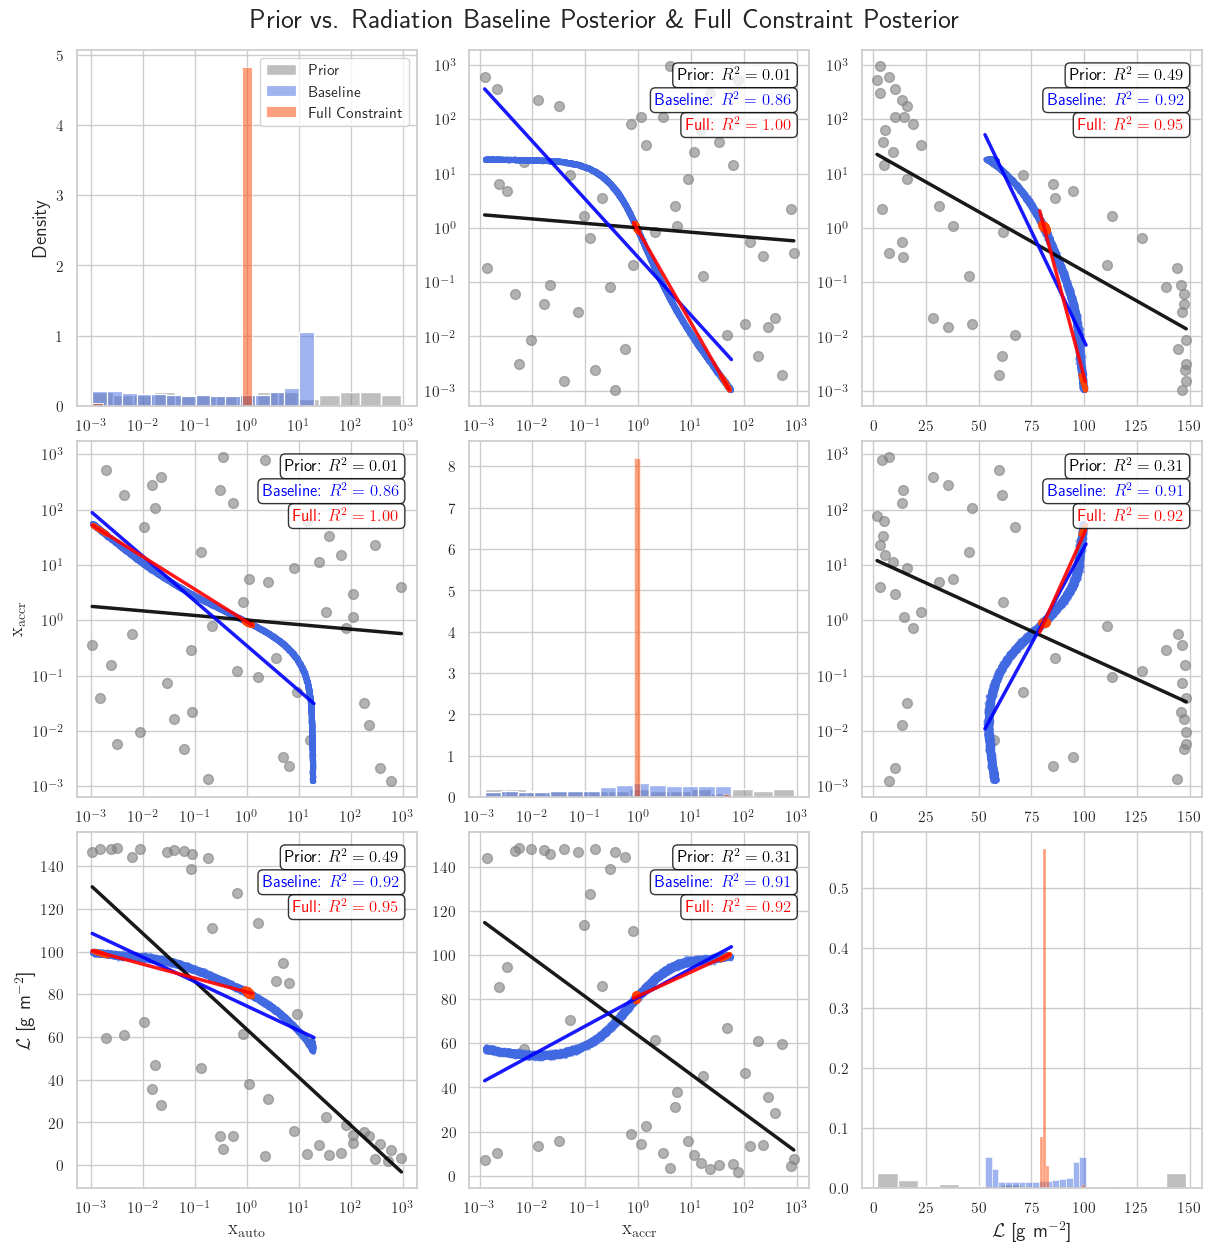

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import joblib
from scipy.stats import linregress

# ==============================================================================
# 1. LOAD DATA
# ==============================================================================
print("--- Loading data from pickle file ---")
thin_bool = True
exp_baseline = 'Radiation_Baseline'
exp_full = 'Radiation_plus_LWP_CDNC_Reff_LCC_PRECL_AUTOCONV_ACCRETN'
# Load the dictionary files
baseline_filename = f'./mcmc_plot_data/plot_data_{exp_baseline}_impact_{"thin" if thin_bool else "nothin"}.pkl'
full_filename = f'./mcmc_plot_data/plot_data_{exp_full}_impact_{"thin" if thin_bool else "nothin"}.pkl'
with open(baseline_filename, "rb") as file:
    plot_data_baseline = pickle.load(file)
with open(full_filename, "rb") as file:
    plot_data_full = pickle.load(file)
# The Prior is your original 50-member ensemble DataFrame
df_prior = df_regime2.copy()

# ==============================================================================
# 2. EXTRACT DATA AND CREATE DATAFRAMES
# ==============================================================================
print("--- Building DataFrames ---")
plot_vars = ['x_auto', 'x_accr', 'LWP_PD']
log_vars_set = {'x_auto', 'x_accr'}
posterior_data = {
    'x_auto': plot_data_baseline['posteriors']['inputs']['x_auto'],
    'x_accr': plot_data_baseline['posteriors']['inputs']['x_accr'],
    'LWP_PD': plot_data_baseline['posteriors']['LWP_PD']
}
full_posterior_data = {
    'x_auto': plot_data_full['posteriors']['inputs']['x_auto'],
    'x_accr': plot_data_full['posteriors']['inputs']['x_accr'],
    'LWP_PD': plot_data_full['posteriors']['LWP_PD']
}

# --- THIS IS THE ONLY CHANGE (Adding the labels dictionary) ---
labels = {
    'x_auto': r'$\mathrm{x_{auto}}$',
    'x_accr': r'$\mathrm{x_{accr}}$',
    'LWP_PD': r'$\mathcal{L}$ [g m$^{-2}$]',
}
# -------------------------------------------------------------

df_baseline = pd.DataFrame(posterior_data)
df_full = pd.DataFrame(full_posterior_data)
#n_plot_samples = 2000
n_plot_samples = len(df_baseline)
if len(df_baseline) > n_plot_samples:
    df_baseline_sample = df_baseline.sample(n=n_plot_samples, random_state=42)
else:
    df_baseline_sample = df_baseline
if len(df_full) > n_plot_samples:
    df_full_sample = df_full.sample(n=n_plot_samples, random_state=42)
else:
    df_full_sample = df_full
print("DataFrames are ready.")

# ==============================================================================
# 3. CREATE THE PAIR PLOT MANUALLY
# ==============================================================================
print("--- Creating Plot ---")
num_vars = len(plot_vars)
fig, axes = plt.subplots(num_vars, num_vars, figsize=(12, 12), constrained_layout=True)
fig.suptitle("Prior vs. Radiation Baseline Posterior \& Full Constraint Posterior", y=1.03, fontsize=20)
Fontsize = 14
for i in range(num_vars):
    for j in range(num_vars):
        ax = axes[i, j]
        x_name = plot_vars[j]
        y_name = plot_vars[i]
        is_log_x = x_name in log_vars_set
        is_log_y = y_name in log_vars_set
        
        if i == j:
            sns.histplot(data=df_prior, x=x_name, ax=ax, stat='density', color='gray', alpha=0.5, log_scale=is_log_x, label='Prior', bins=15)
            sns.histplot(data=df_baseline_sample, x=x_name, ax=ax, stat='density', color='royalblue', alpha=0.5, log_scale=is_log_x, label='Baseline', bins=15)
            sns.histplot(data=df_full_sample, x=x_name, ax=ax, stat='density', color='orangered', alpha=0.5, log_scale=is_log_x, label='Full Constraint', bins=15)
            if i == 0:
                ax.legend()
        else:
            ax.scatter(df_prior[x_name], df_prior[y_name], color='gray', s=50, alpha=0.6)
            ax.scatter(df_baseline_sample[x_name], df_baseline_sample[y_name], color='royalblue', s=5, alpha=0.4)
            ax.scatter(df_full_sample[x_name], df_full_sample[y_name], color='orangered', s=5, alpha=0.4)
            if is_log_x: ax.set_xscale('log')
            if is_log_y: ax.set_yscale('log')
            
            for df, color, source_name, y_pos in [(df_prior, 'black', 'Prior', 0.95), (df_baseline_sample, 'blue', 'Baseline', 0.88), (df_full_sample, 'red', 'Full', 0.81)]:
                x_corr = np.log10(df[x_name]) if is_log_x else df[x_name]
                y_corr = np.log10(df[y_name]) if is_log_y else df[y_name]
                finite_mask = np.isfinite(x_corr) & np.isfinite(y_corr)
                if finite_mask.sum() > 1:
                    slope, intercept, r_value, _,_ = linregress(x_corr[finite_mask], y_corr[finite_mask])
                    r_squared = r_value**2
                    ax.text(0.95, y_pos, f"{source_name}: $R^2={r_squared:.2f}$",
                            transform=ax.transAxes, fontsize=Fontsize-2,
                            verticalalignment='top', color=color,ha='right',
                            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8, ec='black'))
                    x_min, x_max = df[x_name].min(), df[x_name].max()
                    if is_log_x:
                        if x_min <= 0: x_min = 1e-4
                        x_line = np.logspace(np.log10(x_min), np.log10(x_max), 100)
                    else:
                        x_line = np.linspace(x_min, x_max, 100)
                    x_line_transformed = np.log10(x_line) if is_log_x else x_line
                    y_line_transformed = slope * x_line_transformed + intercept
                    y_line_final = 10**y_line_transformed if is_log_y else y_line_transformed
                    ax.plot(x_line, y_line_final, color=color, linewidth=2.5, alpha=0.9)
        
        # --- THIS IS THE ONLY CHANGE ---
        # Look up the label from your dictionary. Use the raw name as a fallback.
        if i == num_vars - 1: 
            ax.set_xlabel(labels.get(x_name, x_name), fontsize=Fontsize)
        if j == 0: 
            ax.set_ylabel(labels.get(y_name, y_name), fontsize=Fontsize)
        # -------------------------------
        
        if i < num_vars - 1: ax.set_xlabel('')
        if j > 0: ax.set_ylabel('')
        if i == j and j > 0: ax.set_ylabel('')

# Set density label only on the first diagonal plot
axes[0,0].set_ylabel('Density', fontsize=Fontsize)
plt.show()


--- Loading data from pickle file ---
--- Building DataFrames ---
DataFrames are ready.
--- Creating Plot ---


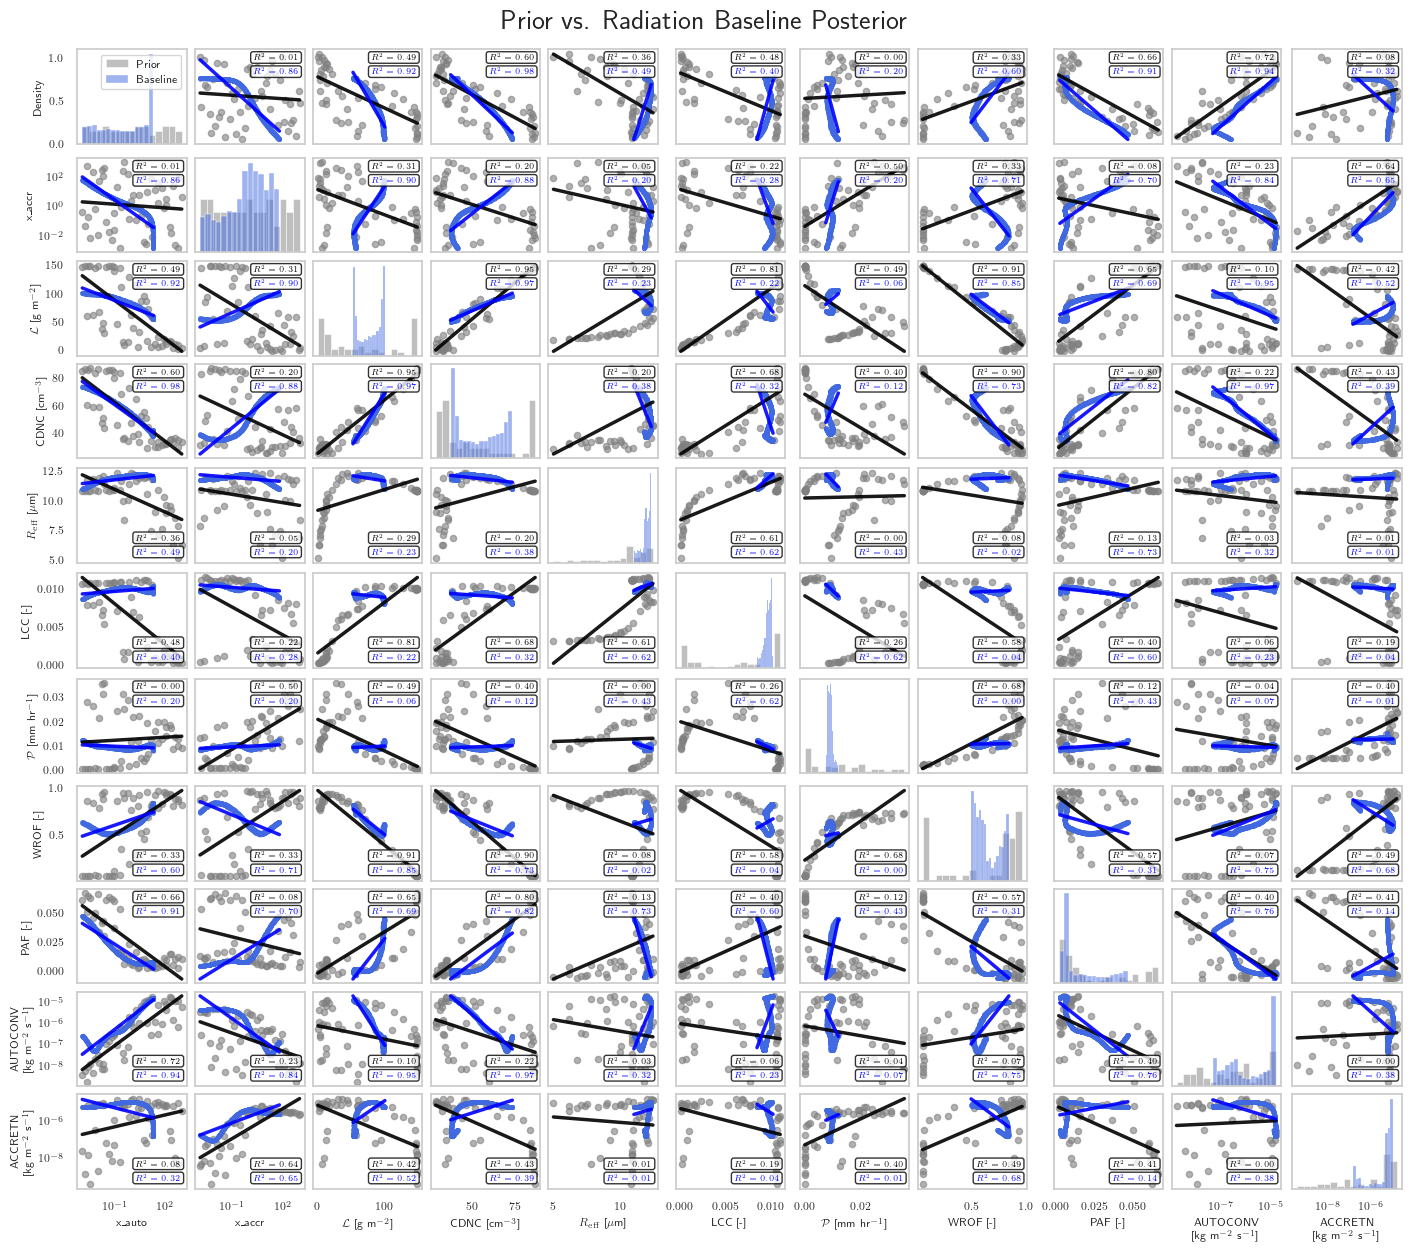

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import joblib
from scipy.stats import linregress

# ==============================================================================
# 1. LOAD DATA
# ==============================================================================
print("--- Loading data from pickle file ---")
thin_bool = True
exp_baseline = 'Radiation_Baseline'
# Load the single dictionary we need
baseline_filename = f'./mcmc_plot_data/plot_data_{exp_baseline}_impact_{"thin" if thin_bool else "nothin"}.pkl'
with open(baseline_filename, "rb") as file:
    plot_data_baseline = pickle.load(file)
# The Prior is your original 50-member ensemble DataFrame
df_prior = df_regime2.copy()

# ==============================================================================
# 2. EXTRACT DATA AND CREATE DATAFRAMES
# ==============================================================================
print("--- Building DataFrames ---")
plot_vars = ['x_auto', 'x_accr', 'LWP_PD','CDNC_PD','REFF_PD','GLOBAL_LCC_PD','PRECL_PD','WROF_PD','PAF_PD','AUTOCONV_PD','ACCRETN_PD']
log_vars_set = {'x_auto', 'x_accr','AUTOCONV_PD','ACCRETN_PD'}
posterior_data = {
    'x_auto': plot_data_baseline['posteriors']['inputs']['x_auto'],
    'x_accr': plot_data_baseline['posteriors']['inputs']['x_accr'],
    'LWP_PD': plot_data_baseline['posteriors']['LWP_PD'],
    'CDNC_PD': plot_data_baseline['posteriors']['CDNC_PD'],
    'REFF_PD': plot_data_baseline['posteriors']['REFF_PD'],
    'GLOBAL_LCC_PD': plot_data_baseline['posteriors']['GLOBAL_LCC_PD'],
    'PRECL_PD': plot_data_baseline['posteriors']['PRECL_PD'],
    'WROF_PD': plot_data_baseline['posteriors']['WROF_PD'],
    'PAF_PD': plot_data_baseline['posteriors']['PAF_PD'],
    'AUTOCONV_PD': plot_data_baseline['posteriors']['AUTOCONV_PD'],
    'ACCRETN_PD': plot_data_baseline['posteriors']['ACCRETN_PD'],
}
labels = {
    'x_auto':'x_auto',
    'x_accr':'x_accr',
    'LWP_PD':r'$\mathcal{L}$ [g m$^{-2}$]',
    'CDNC_PD':r'CDNC [cm$^{-3}$]',
    'REFF_PD':r'$R_{\mathrm{eff}}$ [$\mu$m]',
    'GLOBAL_LCC_PD':'LCC [-]',
    'PRECL_PD':r'$\mathcal{P}$ [mm hr$^{-1}$]',
    'WROF_PD':r'WROF [-]',
    'PAF_PD':r'PAF [-]',
    'AUTOCONV_PD':r'AUTOCONV' + '\n' + r'[kg m$^{-2}$ s$^{-1}$]', # Added newline
    'ACCRETN_PD':r'ACCRETN' + '\n' + r'[kg m$^{-2}$ s$^{-1}$]', # Added newline
}
df_baseline = pd.DataFrame(posterior_data)
n_plot_samples = 2000
if len(df_baseline) > n_plot_samples:
    df_baseline_sample = df_baseline.sample(n=n_plot_samples, random_state=42)
else:
    df_baseline_sample = df_baseline
print("DataFrames are ready.")

# ==============================================================================
# 3. CREATE THE PAIR PLOT MANUALLY
# ==============================================================================
print("--- Creating Plot ---")
num_vars = len(plot_vars)
fig, axes = plt.subplots(num_vars, num_vars, figsize=(14, 12), constrained_layout=True)
fig.suptitle("Prior vs. Radiation Baseline Posterior", y=1.03, fontsize=20)
Fontsize = 8
for i in range(num_vars):
    for j in range(num_vars):
        ax = axes[i, j]
        x_name = plot_vars[j]
        y_name = plot_vars[i]
        is_log_x = x_name in log_vars_set
        is_log_y = y_name in log_vars_set
        
        if i == j:
            sns.histplot(data=df_prior, x=x_name, ax=ax, stat='density', color='gray', alpha=0.5, log_scale=is_log_x, label='Prior', bins=15)
            sns.histplot(data=df_baseline_sample, x=x_name, ax=ax, stat='density', color='royalblue', alpha=0.5, log_scale=is_log_x, label='Baseline', bins=15)
            if i == 0:
                ax.legend(fontsize=Fontsize)
        else:
            ax.scatter(df_prior[x_name], df_prior[y_name], color='gray', s=20, alpha=0.6)
            ax.scatter(df_baseline_sample[x_name], df_baseline_sample[y_name], color='royalblue', s=5, alpha=0.4)
            if is_log_x: ax.set_xscale('log')
            if is_log_y: ax.set_yscale('log')

            if (y_name == 'REFF_PD') or (y_name == 'GLOBAL_LCC_PD') or (y_name == 'WROF_PD') or (y_name == 'AUTOCONV_PD') or (y_name == 'ACCRETN_PD'):
                dum_ypos = 0.3
            else:
                dum_ypos = 0.95
            for df, color, source_name, y_pos in [(df_prior, 'black', 'Prior', dum_ypos), (df_baseline_sample, 'blue', 'Posterior', dum_ypos-0.15)]:
                x_corr = np.log10(df[x_name]) if is_log_x else df[x_name]
                y_corr = np.log10(df[y_name]) if is_log_y else df[y_name]
                finite_mask = np.isfinite(x_corr) & np.isfinite(y_corr)
                if finite_mask.sum() > 1:
                    slope, intercept, r_value, _,_ = linregress(x_corr[finite_mask], y_corr[finite_mask])
                    r_squared = r_value**2
                    ax.text(0.95, y_pos, f"$R^2={r_squared:.2f}$",
                            transform=ax.transAxes, fontsize=Fontsize*0.7,
                            verticalalignment='top', color=color,ha='right',
                            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8, ec='black'))
                    x_min, x_max = df[x_name].min(), df[x_name].max()
                    if is_log_x:
                        if x_min <= 0: x_min = 1e-4
                        x_line = np.logspace(np.log10(x_min), np.log10(x_max), 100)
                    else:
                        x_line = np.linspace(x_min, x_max, 100)
                    x_line_transformed = np.log10(x_line) if is_log_x else x_line
                    y_line_transformed = slope * x_line_transformed + intercept
                    y_line_final = 10**y_line_transformed if is_log_y else y_line_transformed
                    ax.plot(x_line, y_line_final, color=color, linewidth=2.5, alpha=0.9)
        
        # --- Common formatting for all axes in the loop ---
        ax.tick_params(labelsize=Fontsize)
        ax.grid(False)
        
        # --- THIS IS THE ONLY CHANGE ---
        # Set axis labels and then remove interior tick labels
        if i == num_vars - 1: 
            ax.set_xlabel(labels.get(x_name, x_name), fontsize=Fontsize)
        else:
            # Turn off x-axis tick labels for all non-bottom-row plots
            ax.tick_params(axis='x', labelbottom=False)
            ax.set_xlabel('')

        if j == 0:
            ax.set_ylabel(labels.get(y_name, y_name), fontsize=Fontsize)
            # Special handling for the diagonal plot's y-label
            if i == j:
                ax.set_ylabel('Density', fontsize=Fontsize)
        else:
            # Turn off y-axis tick labels for all non-first-column plots
            ax.tick_params(axis='y', labelleft=False)
            ax.set_ylabel('')
        # ---------------------------------

# Set density label only on the first diagonal plot if it wasn't already set
if axes[0,0].get_ylabel() == '':
    axes[0,0].set_ylabel('Density', fontsize=Fontsize)
    
plt.show()
